# Nutrisee — Data Cleaning & Preprocessing Pipeline

**Source**: `recipes-with-nutrition.csv` (original raw data)  
**Output**: `final_recipes_cleaned.csv` (clean then fully encoded, model-ready)

> **Before running**: close `final_recipes_cleaned.csv` in Excel.

| Step | Action |
|---|---|
| 1 | Load source, drop junk columns, remove duplicates |
| 2 | Filter halal-compliant recipes (remove restricted ingredients) |
| 3 | Extract per-serving nutrition (8 values: calories, protein, carbs, fat, fiber, sugar, sodium, cholesterol) |
| 4 | Clean categorical string columns (`cuisine_type`, `meal_type`, `dish_type`, `diet_labels`, etc.) |
| 5 | Fill missing values (nutrition → 0, strings → 'unknown') |
| 6 | One-hot encode `cuisine_type`, `meal_type`, `dish_type` (70 columns) |
| 7 | MultiLabelBinarizer for `diet_labels`, `health_labels`, `cautions` (51 columns) |
| 8 | Simplified ingredient encoding (4,703 unique → ~700 simplified categories, removed from final CSV) |
| 9 | Extract raw ingredients, convert to JSON, save final CSV + preprocessors |

## Step 1 — Load & Drop Junk Columns

In [ ]:
import pandas as pd
import numpy as np
import json
import ast
import pickle
import os
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('recipes-with-nutrition.csv', encoding='latin-1')

# Drop all empty Unnamed columns
unnamed = [c for c in df.columns if c.startswith('Unnamed')]
df.drop(columns=unnamed, inplace=True)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns (dropped {len(unnamed)} empty cols)')

# Drop irrelevant columns (but KEEP total_weight_g)
drop_these = ['daily_values', 'digest', 'ingredient_lines']
df.drop(columns=[c for c in drop_these if c in df.columns], inplace=True)

# Clean title / recipe name and remove empty records before de-duplication
title_col = 'title' if 'title' in df.columns else ('recipe_name' if 'recipe_name' in df.columns else None)
if title_col is not None:
    df[title_col] = df[title_col].astype(str).str.strip()
    df = df[df[title_col].notna() & df[title_col].ne('') & df[title_col].str.lower().ne('nan')]

if 'cuisine_type' in df.columns:
    df['cuisine_type'] = df['cuisine_type'].astype(str).str.strip()
    df = df[df['cuisine_type'].notna() & df['cuisine_type'].ne('') & df['cuisine_type'].str.lower().ne('nan')]

ingredient_col = next((c for c in ['ingredients_json', 'ingredients', 'ingredient_lines'] if c in df.columns), None)
if ingredient_col is not None:
    df[ingredient_col] = df[ingredient_col].fillna('').astype(str).str.strip()
    df = df[df[ingredient_col].ne('') & ~df[ingredient_col].isin(['[]', 'nan', 'None', 'null'])]

# Drop duplicate recipes
before = len(df)
if title_col is not None:
    df.drop_duplicates(subset=[title_col], inplace=True)
else:
    df.drop_duplicates(inplace=True)
print(f'Dropped {before - len(df):,} duplicate rows. Remaining: {len(df):,}')
print('Columns:', df.columns.tolist())
df.head(2)

In [ ]:
# Define restricted ingredients for halal filtering
alcoholic_drinks = ['brandy', 'bourbon', 'whiskey', 'rum', 'gin', 'vodka', 'champagne', 'wine', 
                    'port', 'prosecco', 'chardonnay', 'gewurztraminer', 'tequila', 'mezcal', 
                    'cognac', 'campari', 'cointreau', 'grand marnier', 'pernod', 'cachaca', 'aquavit']

pork_derivatives = ['pork', 'bacon', 'ham', 'prosciutto', 'pancetta', 'pork chops', 'pork loin', 
                    'pork belly', 'chorizo', 'pepperoni', 'sausage']

animal_fats_gelatin = ['lard', 'gelatin']

uncertain_cheeses = ['blue cheese', 'gorgonzola', 'parmesan', 'pecorino', 'manchego']

all_restricted_ingredients = alcoholic_drinks + pork_derivatives + animal_fats_gelatin + uncertain_cheeses

# Filter function
def filter_restricted_recipes(ingredients_json_str):
    """Return True to keep recipe, False to drop it"""
    try:
        if not isinstance(ingredients_json_str, str):
            return True
        ingredients_list = json.loads(ingredients_json_str)
        for ingredient_obj in ingredients_list:
            if isinstance(ingredient_obj, dict) and 'food' in ingredient_obj:
                food_name = ingredient_obj['food'].lower()
                for restricted in all_restricted_ingredients:
                    if restricted.lower() in food_name:
                        return False  # Drop this recipe
    except:
        pass
    return True  # Keep this recipe

# Apply filter
recipes_before = len(df)
mask = df['ingredients'].apply(filter_restricted_recipes)
df = df[mask].reset_index(drop=True)
recipes_dropped = recipes_before - len(df)

print(f'Halal-compliant filtering:')
print(f'  Before: {recipes_before:,} recipes')
print(f'  Dropped: {recipes_dropped:,} recipes ({recipes_dropped/recipes_before*100:.2f}%)')
print(f'  After:  {len(df):,} recipes [OK]')


Halal-compliant filtering:
  Before: 38,242 recipes
  Dropped: 15,137 recipes (39.58%)
  After:  23,105 recipes [OK]


## Step 1.5 — Filter Halal-Compliant Recipes

Remove recipes containing restricted ingredients (alcoholic drinks, pork, non-halal fats & gelatin, uncertain cheeses).


## Step 2 — Per-Serving Nutrition from `total_nutrients` ÷ `servings`

Keeps only the **8 most important** nutrition values, all divided by servings count.

In [ ]:
NUTRIENT_KEYS = {
    'ENERC_KCAL': 'calories',
    'PROCNT':     'protein_g',
    'CHOCDF':     'carbs_g',
    'FAT':        'fat_g',
    'FIBTG':      'fiber_g',
    'SUGAR':      'sugar_g',
    'NA':         'sodium_mg',
    'CHOLE':      'cholesterol_mg',
}

def extract_nutrients_per_serving(row):
    servings = max(float(row.get('servings', 1) or 1), 1)
    result = {}
    try:
        nutrients = json.loads(row['total_nutrients']) if isinstance(row['total_nutrients'], str) else {}
        for key, col_name in NUTRIENT_KEYS.items():
            qty = nutrients.get(key, {}).get('quantity', 0) or 0
            # Divide by servings and ensure no negative values
            per_serving = float(qty) / servings
            result[f'{col_name}_per_serving'] = max(0, round(per_serving, 4))
    except Exception:
        for col_name in NUTRIENT_KEYS.values():
            result[f'{col_name}_per_serving'] = 0.0
    return pd.Series(result)

print('Extracting per-serving nutrition (this may take a moment)...')
nutrition_df = df.apply(extract_nutrients_per_serving, axis=1)
df = pd.concat([df, nutrition_df], axis=1)
df.drop(columns=['calories', 'total_nutrients', 'servings'], inplace=True)

nutrition_cols = list(nutrition_df.columns)
print(f'Nutrition columns: {nutrition_cols}')
df[nutrition_cols].describe().round(2)
df.shape

Extracting per-serving nutrition (this may take a moment)...
Nutrition columns: ['calories_per_serving', 'protein_g_per_serving', 'carbs_g_per_serving', 'fat_g_per_serving', 'fiber_g_per_serving', 'sugar_g_per_serving', 'sodium_mg_per_serving', 'cholesterol_mg_per_serving']


(23105, 20)

## Step 3 — Clean Categorical Columns

In [ ]:
def parse_json_list(val):
    """Parse a JSON/ast list string. Returns list of lowercase strings."""
    if pd.isna(val) or str(val).strip() in ('', '[]', 'nan'):
        return []
    for parser in [json.loads, ast.literal_eval]:
        try:
            parsed = parser(val)
            if isinstance(parsed, list):
                return [str(x).strip().lower() for x in parsed if x]
        except Exception:
            pass
    return [str(val).strip().lower()]

# Single-value → extract first item as plain string
for col in ['cuisine_type', 'meal_type', 'dish_type']:
    df[col] = df[col].apply(lambda v: parse_json_list(v)[0] if parse_json_list(v) else 'unknown')
    print(f'  {col}: {df[col].nunique()} unique values | sample: {df[col].unique()[:5].tolist()}')

# Multi-value → join as comma-separated string
for col in ['diet_labels', 'health_labels', 'cautions']:
    df[col] = df[col].apply(lambda v: ', '.join(parse_json_list(v)) if parse_json_list(v) else 'unknown')
    if len(df) > 0:
        print(f'  {col}: sample = {repr(df[col].iloc[0][:70])}')
    else:
        print(f'  {col}: (no data - empty dataframe)')

  cuisine_type: 24 unique values | sample: ['american', 'french', 'nordic', 'mexican', 'mediterranean']
  meal_type: 11 unique values | sample: ['lunch/dinner', 'snack', 'breakfast', 'main course', 'brunch']
  dish_type: 35 unique values | sample: ['salad', 'desserts', 'drinks', 'main course', 'biscuits and cookies']
  diet_labels: sample = 'balanced'
  health_labels: sample = 'vegetarian, gluten-free, peanut-free, tree-nut-free, soy-free, fish-fr'
  cautions: sample = 'unknown'


## Step 4 — Fill Missing Values

In [ ]:
df[nutrition_cols] = df[nutrition_cols].fillna(0)
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].fillna('unknown')

print(f'Nulls remaining: {df.isna().sum().sum()}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Nulls remaining: 0
Shape: 23,105 rows x 20 columns


,recipe_name,source,url,total_weight_g,image_url,diet_labels,health_labels,cautions,cuisine_type,meal_type,dish_type,ingredients,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,sugar_g_per_serving,sodium_mg_per_serving,cholesterol_mg_per_serving
0,Classic Cabbage Slaw with Grandmother Shinn's ...,Food Network,https://www.foodnetwork.com/recipes/classic-ca...,1239.311258661114,https://datahive-prod-dataset-products.s3.eu-c...,balanced,"vegetarian, gluten-free, peanut-free, tree-nut...",unknown,american,lunch/dinner,salad,"[{""food"":""kosher salt"",""text"":""1 tablespoon ko...",85.2139,3.2662,12.4207,2.5437,2.1056,9.2755,477.7898,64.36
1,The Macaron Frapp?,French Revolution Food,http://www.frenchrevolutionfood.com/2013/07/le...,438.7629981,https://datahive-prod-dataset-products.s3.eu-c...,unknown,"vegetarian, peanut-free, tree-nut-free, soy-fr...",sulfites,french,snack,desserts,"[{""food"":""macaron"",""text"":""1 macaron (about ? ...",276.2439,6.5811,30.1070,14.4285,1.1849,26.5600,148.8847,41.24
2,Sparkling Berry Lemonade,nourishnutritionblog.com,https://nourishnutritionblog.com/sparkling-ber...,1160,https://datahive-prod-dataset-products.s3.eu-c...,"low-fat, low-sodium","vegan, vegetarian, dairy-free, gluten-free, eg...",sulfites,american,snack,drinks,"[{""food"":""lemonade"",""text"":""2 cups lemonade"",""...",61.2800,0.5092,15.3144,0.3336,1.5200,12.9564,47.8000,0.00


---
## Step 6 — One-Hot Encode: `cuisine_type`, `meal_type`, `dish_type`

In [ ]:
df = pd.get_dummies(df, columns=['cuisine_type', 'meal_type'],
                    prefix=['cuisine_type', 'meal_type'])
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(np.uint8)

# Drop ALL dish_type columns (not used in recommendations)
dish_type_cols = [c for c in df.columns if c.startswith('dish_type')]
if dish_type_cols:
    df.drop(columns=dish_type_cols, inplace=True)
    print(f'[DROP] Removed {len(dish_type_cols)} dish_type columns')

print(f'Columns after one-hot: {df.shape[1]}')

[DROP] Removed 1 dish_type columns
Columns after one-hot: 52


## Step 7 — MultiLabelBinarizer: `diet_labels`, `health_labels`, `cautions`

In [ ]:
mlb_objects = {}

def split_labels(val):
    if pd.isna(val) or str(val).strip() == 'unknown':
        return []
    return [x.strip() for x in str(val).split(',') if x.strip() and x.strip() != 'unknown']

for col in ['diet_labels', 'health_labels', 'cautions']:
    lists = df[col].apply(split_labels)
    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(lists)
    encoded_df = pd.DataFrame(
        encoded,
        columns=[f"{col}__{c.replace(' ', '_')}" for c in mlb.classes_],
        index=df.index
    )
    df = pd.concat([df.drop(columns=[col]), encoded_df], axis=1)
    mlb_objects[col] = mlb
    print(f'  {col}: {len(mlb.classes_)} labels -> {list(mlb.classes_)}')

print(f'Columns after MLB: {df.shape[1]}')

  diet_labels: 17 labels -> ['balanced', 'dairy-free', 'egg-free', 'fish-free', 'gluten-free', 'high-fiber', 'high-protein', 'low-carb', 'low-fat', 'low-sodium', 'paleo', 'peanut-free', 'shellfish-free', 'soy-free', 'tree-nut-free', 'vegan', 'vegetarian']
  health_labels: 18 labels -> ['dairy-free', 'egg-free', 'fish-free', 'fodmap', 'gluten', 'gluten-free', 'low sugar', 'paleo', 'peanut-free', 'shellfish-free', 'soy', 'soy-free', 'sulfites', 'tree-nut-free', 'tree-nuts', 'vegan', 'vegetarian', 'wheat']
  cautions: 16 labels -> ['american', 'chinese', 'eggs', 'fodmap', 'french', 'gluten', 'italian', 'mediterranean', 'mexican', 'milk', 'peanuts', 'shellfish', 'soy', 'sulfites', 'tree-nuts', 'wheat']
Columns after MLB: 100


## Step 8 — Ingredient Weights (Frequent Ingredients Only)

---
# ?? Phase 1 ? Fix Retrieval Quality

## Step 1: Upgrade Embeddings

Replace TF-IDF with `sentence-transformers/all-MiniLM-L6-v2`.

## Step 2: Create Better Recipe Representations

Use title, cuisine, meal type, ingredients, tags, and calories in the text passed to the embedding model.

## Step 3: Clean the Dataset

Remove duplicate recipes, missing ingredients, missing cuisines, and empty titles before building the index.


In [ ]:
!pip install sentence-transformers

In [1]:
# Phase 1: Sentence Embeddings + Hybrid Similarity Index

EMBEDDING_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
TOP_CANDIDATES = 500
TOP_STORE = 50
HYBRID_WEIGHTS = {
    'ingredient_similarity': 0.50,
    'calorie_similarity': 0.20,
    'protein_similarity': 0.15,
    'cuisine_similarity': 0.10,
    'meal_type_similarity': 0.05,
}

import os
import json
import re
import pickle
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

print('Phase 1: Sentence Embeddings + Hybrid Recommendation Index')
print('=' * 60)
print(f'Model: {EMBEDDING_MODEL_NAME}')

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    message = (
        'sentence-transformers is required for Phase 1. Install it with:' + chr(10) +
        '    pip install sentence-transformers' + chr(10) +
        'Then re-run this cell to replace TF-IDF with all-MiniLM-L6-v2 embeddings.'
    )
    raise ImportError(message) from exc

if 'df_clean' not in globals():
    df_clean = pd.read_csv('final_recipes_cleaned.csv')
if 'df_ids' not in globals():
    df_ids = pd.read_csv('recipe_identifiers.csv')

def _label_from_one_hot(row, prefix):
    cols = [c for c in row.index if c.startswith(prefix)]
    for col in cols:
        if row[col] == 1:
            return col.replace(prefix, '').replace('_', ' ')
    return 'unknown'

def _label_array(df, prefix):
    return np.array([_label_from_one_hot(df.iloc[i], prefix) for i in range(len(df))], dtype=object)

def _ingredient_names(ingredients_json):
    try:
        items = json.loads(ingredients_json) if isinstance(ingredients_json, str) else []
    except Exception:
        return []

    names = []
    for item in items:
        if not isinstance(item, dict):
            continue
        name = item.get('name') or item.get('food') or item.get('text')
        if name:
            names.append(str(name).strip().lower())
    return names

def _flatten_tag_values(value):
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, (list, tuple, set)):
        raw_items = list(value)
    else:
        text = str(value).strip()
        if not text or text.lower() in {'nan', 'none', 'null', '[]'}:
            return []
        try:
            parsed = json.loads(text)
            if isinstance(parsed, (list, tuple, set)):
                raw_items = list(parsed)
            else:
                raw_items = [parsed]
        except Exception:
            raw_items = re.split(r'[|,;/]+', text)
    tags = []
    for item in raw_items:
        tag = str(item).strip().lower().replace(' ', '_')
        if tag and tag not in {'nan', 'none', 'null', '[]'}:
            tags.append(tag)
    return tags

def _recipe_tags(row):
    tags = []
    for col in ['diet_labels', 'health_labels', 'cautions', 'dish_type', 'tags']:
        if col in row.index:
            tags.extend(_flatten_tag_values(row[col]))
    return sorted(set(tags))

def _title_from_row(row, fallback='Unknown recipe'):
    for col in ['title', 'recipe_name', 'name']:
        if col in row.index:
            value = str(row[col]).strip()
            if value and value.lower() not in {'nan', 'none', 'null'}:
                return value
    return fallback

def _numeric_similarity(a, b, tolerance=0.30):
    baseline = max(abs(float(a)), abs(float(b)), 1.0)
    return float(np.exp(-abs(float(a) - float(b)) / (baseline * tolerance)))

def _categorical_similarity(a, b, mismatch_score, unknown_score=0.5):
    a = str(a or 'unknown').lower().strip()
    b = str(b or 'unknown').lower().strip()
    if a == 'unknown' or b == 'unknown':
        return unknown_score
    return 1.0 if a == b else mismatch_score

def build_semantic_recipe_text(row, recipe_name):
    ingredients = _ingredient_names(row.get('ingredients_json', ''))
    tags = _recipe_tags(row)
    cuisine = _label_from_one_hot(row, 'cuisine_type_')
    meal = _label_from_one_hot(row, 'meal_type_')
    calories = row.get('calories_per_serving', 0)
    sep = chr(10)

    return sep.join([
        f'Title: {recipe_name}',
        f'Cuisine: {cuisine}',
        f'Meal Type: {meal}',
        f'Ingredients: {" ".join(ingredients)}',
        f'Tags: {" ".join(tags)}',
        f'Calories: {calories}',
    ])

recipe_texts = [
    build_semantic_recipe_text(df_clean.iloc[i], _title_from_row(df_ids.iloc[i] if i < len(df_ids) else df_clean.iloc[i]))
    for i in range(len(df_clean))
]

print(f'Encoding {len(recipe_texts):,} recipes...')
model = SentenceTransformer(EMBEDDING_MODEL_NAME)
recipe_embeddings = model.encode(
    recipe_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype('float32')
np.save('recipe_embeddings.npy', recipe_embeddings)

calories = df_clean['calories_per_serving'].fillna(0).to_numpy(float)
protein = df_clean['protein_g_per_serving'].fillna(0).to_numpy(float)
cuisines = _label_array(df_clean, 'cuisine_type_')
meal_types = _label_array(df_clean, 'meal_type_')

print(f'Finding top-{TOP_CANDIDATES} semantic neighbors...')
n_neighbors = min(TOP_CANDIDATES + 1, len(recipe_embeddings))
nn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine', algorithm='brute')
nn.fit(recipe_embeddings)
distances, indices = nn.kneighbors(recipe_embeddings)

ingredient_index = {}
hybrid_index = {}
for query_idx, (neighbor_ids, neighbor_distances) in enumerate(zip(indices, distances)):
    ingredient_scored = []
    hybrid_scored = []

    for neighbor_id, distance in zip(neighbor_ids, neighbor_distances):
        candidate_idx = int(neighbor_id)
        if candidate_idx == query_idx:
            continue

        raw_cosine = float(1.0 - distance)
        ingredient_similarity = float((raw_cosine + 1.0) / 2.0)
        ingredient_scored.append((candidate_idx, ingredient_similarity))

        calorie_similarity = _numeric_similarity(calories[query_idx], calories[candidate_idx])
        protein_similarity = _numeric_similarity(protein[query_idx], protein[candidate_idx])
        cuisine_similarity = _categorical_similarity(cuisines[query_idx], cuisines[candidate_idx], mismatch_score=0.2)
        meal_type_similarity = _categorical_similarity(meal_types[query_idx], meal_types[candidate_idx], mismatch_score=0.3)

        final_score = (
            HYBRID_WEIGHTS['ingredient_similarity'] * ingredient_similarity +
            HYBRID_WEIGHTS['calorie_similarity'] * calorie_similarity +
            HYBRID_WEIGHTS['protein_similarity'] * protein_similarity +
            HYBRID_WEIGHTS['cuisine_similarity'] * cuisine_similarity +
            HYBRID_WEIGHTS['meal_type_similarity'] * meal_type_similarity
        )
        hybrid_scored.append((candidate_idx, float(final_score)))

    ingredient_scored.sort(key=lambda item: item[1], reverse=True)
    hybrid_scored.sort(key=lambda item: item[1], reverse=True)
    ingredient_index[int(query_idx)] = ingredient_scored[:TOP_CANDIDATES]
    hybrid_index[int(query_idx)] = hybrid_scored[:TOP_STORE]

metadata = {
    'model_type': 'sentence_embeddings_hybrid',
    'embedding_model': EMBEDDING_MODEL_NAME,
    'similarity_index_type': 'hybrid_score',
    'ingredient_similarity_index_file': 'recipe_ingredient_similarity_index.pkl',
    'ingredient_similarity_calibration': '(cosine + 1) / 2',
    'ingredient_index_size': TOP_CANDIDATES,
    'candidate_pool_size': TOP_CANDIDATES,
    'hybrid_index_size': TOP_STORE,
    'hybrid_weights': HYBRID_WEIGHTS,
    'recipe_names': df_ids['recipe_name'].tolist(),
    'recipe_ids': list(range(len(df_clean))),
    'total_weights': df_clean['total_weight_g'].fillna(0).tolist(),
    'calories': calories.tolist(),
    'protein_g': protein.tolist(),
    'cuisine_type': cuisines.tolist(),
    'meal_type': meal_types.tolist(),
    'normalized_ingredients': [_ingredient_names(x) for x in df_clean['ingredients_json'].fillna('[]')],
    'sources': df_ids['source'].fillna('unknown').tolist(),
    'urls': df_ids['url'].fillna('').tolist(),
}

with open('recipe_ingredient_similarity_index.pkl', 'wb') as f:
    pickle.dump(ingredient_index, f, protocol=pickle.HIGHEST_PROTOCOL)
with open('recipe_similarity_index.pkl', 'wb') as f:
    pickle.dump(hybrid_index, f, protocol=pickle.HIGHEST_PROTOCOL)
with open('recommendation_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f, protocol=pickle.HIGHEST_PROTOCOL)

ingredient_top1 = np.array([sims[0][1] for sims in ingredient_index.values() if sims], dtype=float)
hybrid_top1 = np.array([sims[0][1] for sims in hybrid_index.values() if sims], dtype=float)

print('[OK] Saved recipe_embeddings.npy')
print('[OK] Saved recipe_ingredient_similarity_index.pkl with calibrated MiniLM ingredient scores')
print('[OK] Saved recipe_similarity_index.pkl with final hybrid scores')
print('[OK] Saved recommendation_metadata.pkl with hybrid metadata')
print(f'Ingredient Top-1 mean: {ingredient_top1.mean():.4f}')
print(f'Hybrid Top-1 mean    : {hybrid_top1.mean():.4f}')
print(f'Hybrid relevance >= .80: {(hybrid_top1 >= 0.80).mean() * 100:.1f}%')


Phase 1: Sentence Embeddings + Hybrid Recommendation Index
Model: sentence-transformers/all-MiniLM-L6-v2
Encoding 23,904 recipes...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/187 [00:00<?, ?it/s]

Finding top-500 semantic neighbors...
[OK] Saved recipe_embeddings.npy
[OK] Saved recipe_ingredient_similarity_index.pkl with calibrated MiniLM ingredient scores
[OK] Saved recipe_similarity_index.pkl with final hybrid scores
[OK] Saved recommendation_metadata.pkl with hybrid metadata
Ingredient Top-1 mean: 0.9314
Hybrid Top-1 mean    : 0.8709
Hybrid relevance >= .80: 92.7%


In [ ]:
# ── EDA Setup ────────────────────────────────────────────────────────────────
import os
import pickle
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib

# Use inline backend in Jupyter; fall back to Agg in plain Python
try:
    from IPython import get_ipython

    _ipy = get_ipython()
    if _ipy is not None:
        _ipy.run_line_magic('matplotlib', 'inline')
    else:
        matplotlib.use('Agg')
except Exception:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Theme Configuration ──────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#c9d1e0',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'text.color':       '#e0e6f0',
    'grid.color':       '#2a2d3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.facecolor': '#1e2130',
    'legend.edgecolor': '#3a3f5c',
})

ACCENT = '#e94560'
BLUE   = '#53d8fb'
GREEN  = '#4ecdc4'
PURPLE = '#a78bfa'
GOLD   = '#fbbf24'
ORANGE = '#f97316'

print("=" * 80)
print("NUTRISEE RECOMMENDATION SYSTEM - EDA SETUP")
print("=" * 80)

# ── Load CSV Files ───────────────────────────────────────────────────────────
try:
    df_clean = pd.read_csv('final_recipes_cleaned.csv')
    print(f"[OK] final_recipes_cleaned.csv loaded")
    print(f"     Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
except Exception as e:
    print(f"[ERROR] Could not load final_recipes_cleaned.csv")
    print(e)
    raise

try:
    df_ids = pd.read_csv('recipe_identifiers.csv')
    print(f"[OK] recipe_identifiers.csv loaded")
    print(f"     Shape: {df_ids.shape[0]:,} rows × {df_ids.shape[1]} cols")
except Exception as e:
    print(f"[ERROR] Could not load recipe_identifiers.csv")
    print(e)
    raise

# ── Load Recommendation Artifacts ────────────────────────────────────────────
metadata = None
sim_index = None
recipe_embeddings = None

ARTIFACTS = {
    "metadata": "recommendation_metadata.pkl",
    "sim_index": "recipe_similarity_index.pkl",
    "recipe_embeddings": "recipe_embeddings.npy"
}

print("\nLoading recommendation artifacts...")

for var_name, file_name in ARTIFACTS.items():

    if not os.path.exists(file_name):
        print(f"[WARN] Missing: {file_name}")
        continue

    try:
        if file_name.endswith(".npy"):
            globals()[var_name] = np.load(file_name)
        else:
            with open(file_name, "rb") as f:
                globals()[var_name] = pickle.load(f)

        size_mb = os.path.getsize(file_name) / (1024 * 1024)

        print(
            f"[OK] {file_name:<35} "
            f"({size_mb:.2f} MB)"
        )

    except Exception as e:
        print(f"[ERROR] Failed loading {file_name}")
        print(e)

PKL_READY = (
    metadata is not None
    and sim_index is not None
    and recipe_embeddings is not None
)

if PKL_READY:
    print("\n[OK] All recommendation artifacts loaded")
    print("     A7 and Section B analyses are enabled")
else:
    print("\n[INFO] Some artifacts are missing")
    print("       A1-A6 analyses will still work")
    print("       A7 and Section B require Steps 10–10.5")

# ── Decode One-Hot Encoded Columns ───────────────────────────────────────────
cuisine_cols = [
    c for c in df_clean.columns
    if c.startswith("cuisine_type_")
]

meal_cols = [
    c for c in df_clean.columns
    if c.startswith("meal_type_")
]

print("\nDecoding one-hot encoded columns...")

def decode_onehot_fast(df, cols, prefix):
    """
    Convert one-hot columns into categorical labels.
    Much faster than iterrows().
    """

    if len(cols) == 0:
        return pd.Series(["unknown"] * len(df))

    decoded = (
        df[cols]
        .idxmax(axis=1)
        .str.replace(f"{prefix}_", "", regex=False)
    )

    return decoded.fillna("unknown")

if cuisine_cols:
    df_clean["_cuisine"] = decode_onehot_fast(
        df_clean,
        cuisine_cols,
        "cuisine_type"
    )
    print(f"[OK] Decoded {len(cuisine_cols)} cuisine columns")

if meal_cols:
    df_clean["_meal"] = decode_onehot_fast(
        df_clean,
        meal_cols,
        "meal_type"
    )
    print(f"[OK] Decoded {len(meal_cols)} meal columns")

# ── Nutrition Columns Validation ─────────────────────────────────────────────
NUTRITION_COLS = [
    "calories_per_serving",
    "protein_g_per_serving",
    "carbs_g_per_serving",
    "fat_g_per_serving",
    "fiber_g_per_serving",
    "sugar_g_per_serving",
    "sodium_mg_per_serving",
    "cholesterol_mg_per_serving",
]

missing_nutrition = [
    col
    for col in NUTRITION_COLS
    if col not in df_clean.columns
]

print("\nNutrition Validation")

if len(missing_nutrition) == 0:
    print("[OK] All 8 nutrition columns present")
else:
    print("[WARN] Missing nutrition columns:")
    for col in missing_nutrition:
        print(f"   - {col}")

# ── Dataset Summary ──────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

print(f"Recipes                    : {len(df_clean):,}")

if "recipe_name" in df_clean.columns:
    print(
        f"Unique Recipes             : "
        f"{df_clean['recipe_name'].nunique():,}"
    )

print(f"Total Columns              : {df_clean.shape[1]:,}")

if "_cuisine" in df_clean.columns:
    print(
        f"Unique Cuisines            : "
        f"{df_clean['_cuisine'].nunique():,}"
    )

if "_meal" in df_clean.columns:
    print(
        f"Unique Meal Types          : "
        f"{df_clean['_meal'].nunique():,}"
    )

if recipe_embeddings is not None:
    print(
        f"Embedding Matrix Shape     : "
        f"{recipe_embeddings.shape}"
    )

print("\nTop Meal Types:")

if "_meal" in df_clean.columns:
    print(df_clean["_meal"].value_counts().head())

print("\nTop Cuisines:")

if "_cuisine" in df_clean.columns:
    print(df_clean["_cuisine"].value_counts().head())

print("\n[OK] EDA setup completed successfully.")
print("=" * 80)

NUTRISEE RECOMMENDATION SYSTEM - EDA SETUP
[OK] final_recipes_cleaned.csv loaded
     Shape: 23,904 rows × 96 cols
[OK] recipe_identifiers.csv loaded
     Shape: 23,904 rows × 4 cols

Loading recommendation artifacts...
[OK] recommendation_metadata.pkl         (5.45 MB)
[OK] recipe_similarity_index.pkl         (16.11 MB)
[OK] recipe_embeddings.npy               (35.02 MB)

[OK] All recommendation artifacts loaded
     A7 and Section B analyses are enabled

Decoding one-hot encoded columns...
[OK] Decoded 24 cuisine columns
[OK] Decoded 11 meal columns

Nutrition Validation
[OK] All 8 nutrition columns present

DATASET SUMMARY
Recipes                    : 23,904
Total Columns              : 98
Unique Cuisines            : 24
Unique Meal Types          : 11
Embedding Matrix Shape     : (23904, 384)

Top Meal Types:
_meal
lunch/dinner    15913
snack            4609
breakfast        3355
brunch              9
main course         7
Name: count, dtype: int64

Top Cuisines:
_cuisine
american 

## A1 — Dataset Overview


In [ ]:
# A1: Dataset overview
print('=' * 65)
print('  DATASET OVERVIEW')
print('=' * 65)
print(f'  Recipes (rows)   : {df_clean.shape[0]:,}')
print(f'  Features (cols)  : {df_clean.shape[1]}')
print(f'  Missing values   : {df_clean.isna().sum().sum()}')
print(f'  Memory usage     : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('  Nutrition columns summary:')
display(df_clean[NUTRITION_COLS].describe().round(2))


  DATASET OVERVIEW
  Recipes (rows)   : 23,904
  Features (cols)  : 98
  Missing values   : 0
  Memory usage     : 28.8 MB

  Nutrition columns summary:


,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,sugar_g_per_serving,sodium_mg_per_serving,cholesterol_mg_per_serving
count,23904.00,23904.00,23904.00,23904.00,23904.00,23904.00,23904.00,23904.00
mean,334.17,12.36,35.40,16.67,3.64,10.82,387.64,49.66
std,298.90,15.88,37.95,20.70,4.19,22.64,659.66,87.17
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,160.79,2.94,11.97,4.37,0.74,0.00,75.89,0.00
50%,251.60,6.59,26.42,10.72,2.37,2.76,237.32,11.26
75%,397.86,15.17,45.39,20.85,5.24,11.86,515.79,65.82
max,2498.39,197.48,465.77,259.60,55.00,444.51,65486.07,1884.96


## A2 — Nutrition Distributions


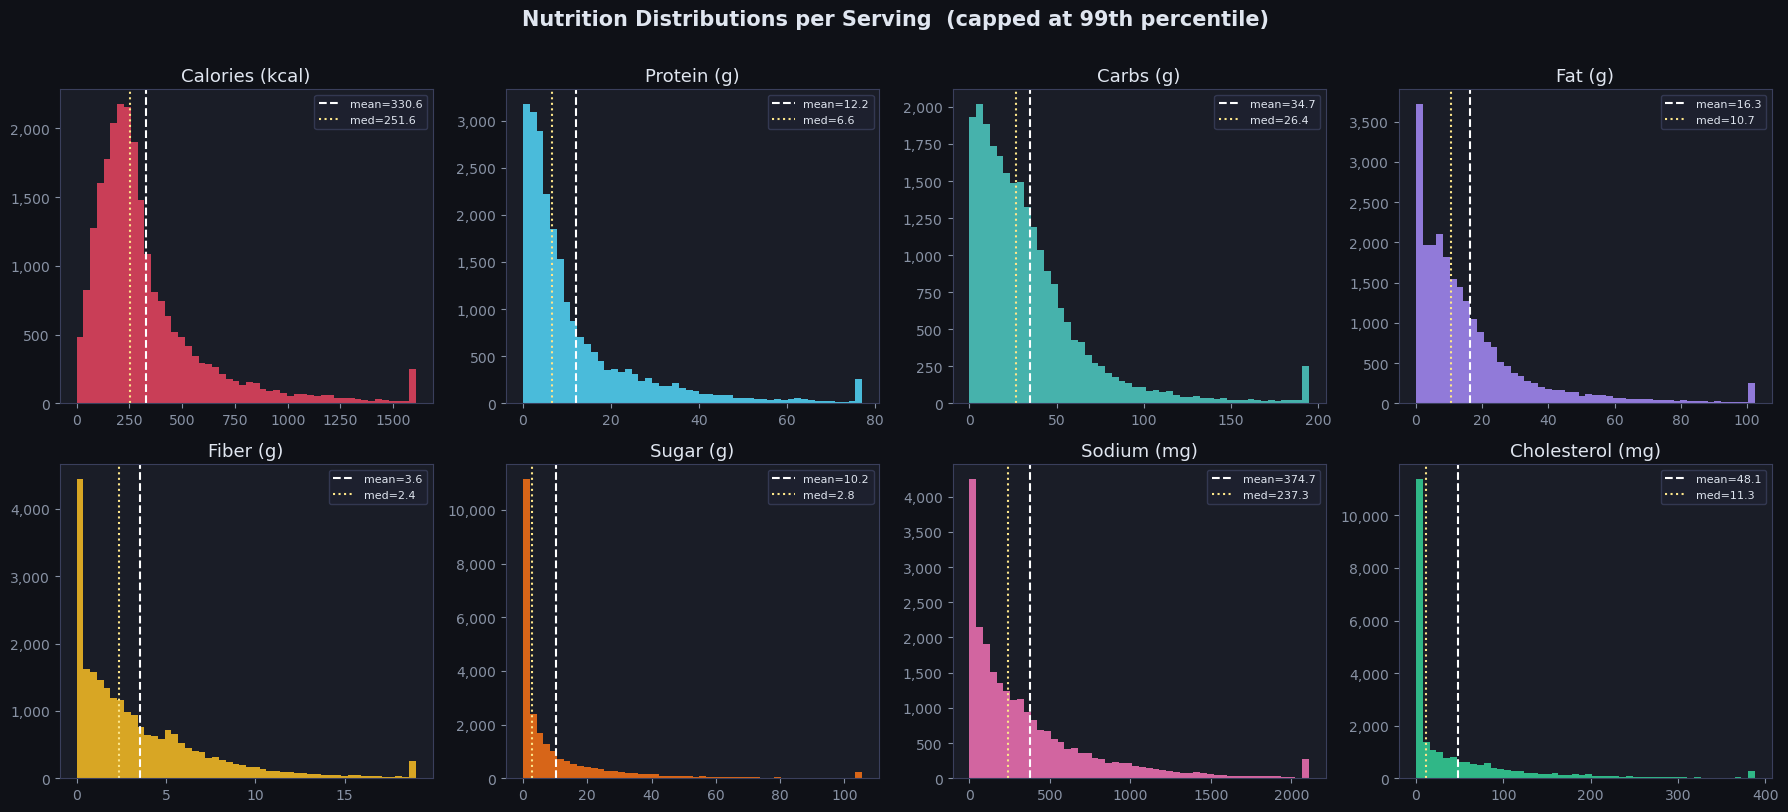

[OK] Saved nutrition_distributions.png


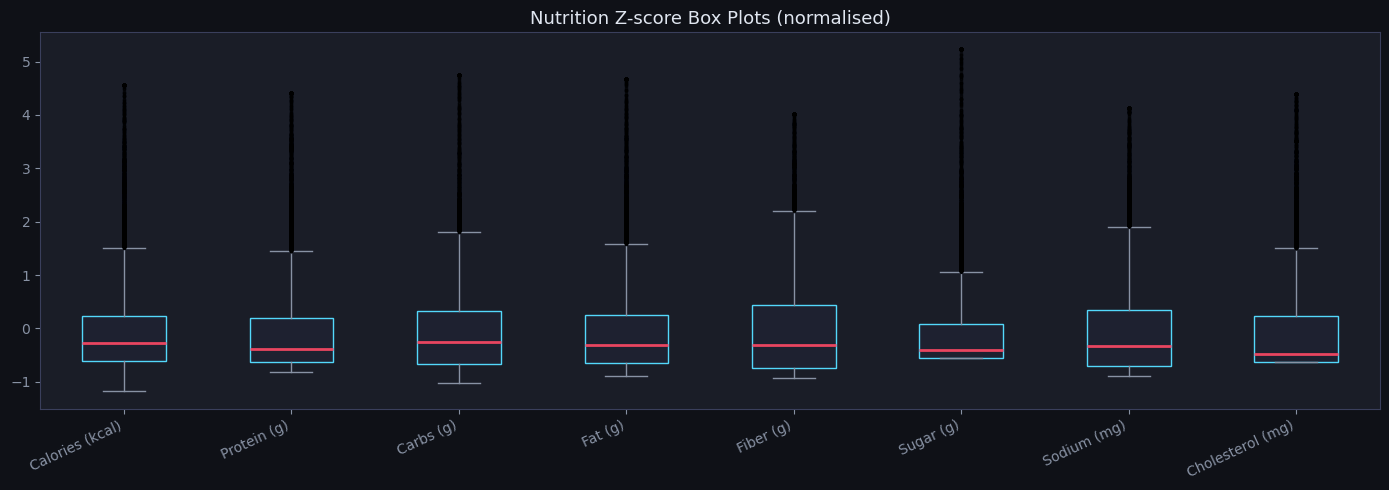

[OK] Saved nutrition_boxplots.png


In [ ]:
# A2: Nutrition distributions — histograms + box plots
LABELS = {
    'calories_per_serving':      'Calories (kcal)',
    'protein_g_per_serving':     'Protein (g)',
    'carbs_g_per_serving':       'Carbs (g)',
    'fat_g_per_serving':         'Fat (g)',
    'fiber_g_per_serving':       'Fiber (g)',
    'sugar_g_per_serving':       'Sugar (g)',
    'sodium_mg_per_serving':     'Sodium (mg)',
    'cholesterol_mg_per_serving':'Cholesterol (mg)',
}

# Cap outliers at 99th percentile for cleaner plots
df_plot = df_clean[NUTRITION_COLS].copy()
for col in NUTRITION_COLS:
    cap = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(upper=cap)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Nutrition Distributions per Serving  (capped at 99th percentile)',
             fontsize=15, color='#e0e6f0', y=1.01, fontweight='bold')

COLORS = [ACCENT, BLUE, GREEN, PURPLE, GOLD, ORANGE, '#f472b6', '#34d399']

for ax, col, lbl, clr in zip(axes.flat, NUTRITION_COLS, LABELS.values(), COLORS):
    data = df_plot[col].dropna()
    ax.hist(data, bins=50, color=clr, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(),   color='white', lw=1.5, linestyle='--', label=f'mean={data.mean():.1f}')
    ax.axvline(data.median(), color='#fde68a', lw=1.5, linestyle=':', label=f'med={data.median():.1f}')
    ax.set_title(lbl, color='#e0e6f0')
    ax.set_xlabel('')
    ax.legend(fontsize=8, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('nutrition_distributions.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('[OK] Saved nutrition_distributions.png')

# Box plots side by side (normalised Z-score for comparability)
from scipy.stats import zscore
df_z = df_plot[NUTRITION_COLS].apply(zscore)
df_z.columns = [LABELS[c] for c in NUTRITION_COLS]

fig2, ax2 = plt.subplots(figsize=(14, 5))
df_z.plot.box(ax=ax2, patch_artist=True,
              boxprops=dict(facecolor='#1e2130', color=BLUE),
              medianprops=dict(color=ACCENT, linewidth=2),
              whiskerprops=dict(color='#8892a4'),
              capprops=dict(color='#8892a4'),
              flierprops=dict(marker='.', color=ACCENT, alpha=0.3, markersize=3))
ax2.set_title('Nutrition Z-score Box Plots (normalised)', fontsize=13, color='#e0e6f0')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.savefig('nutrition_boxplots.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('[OK] Saved nutrition_boxplots.png')


## A3 — Cuisine & Meal-Type Breakdown


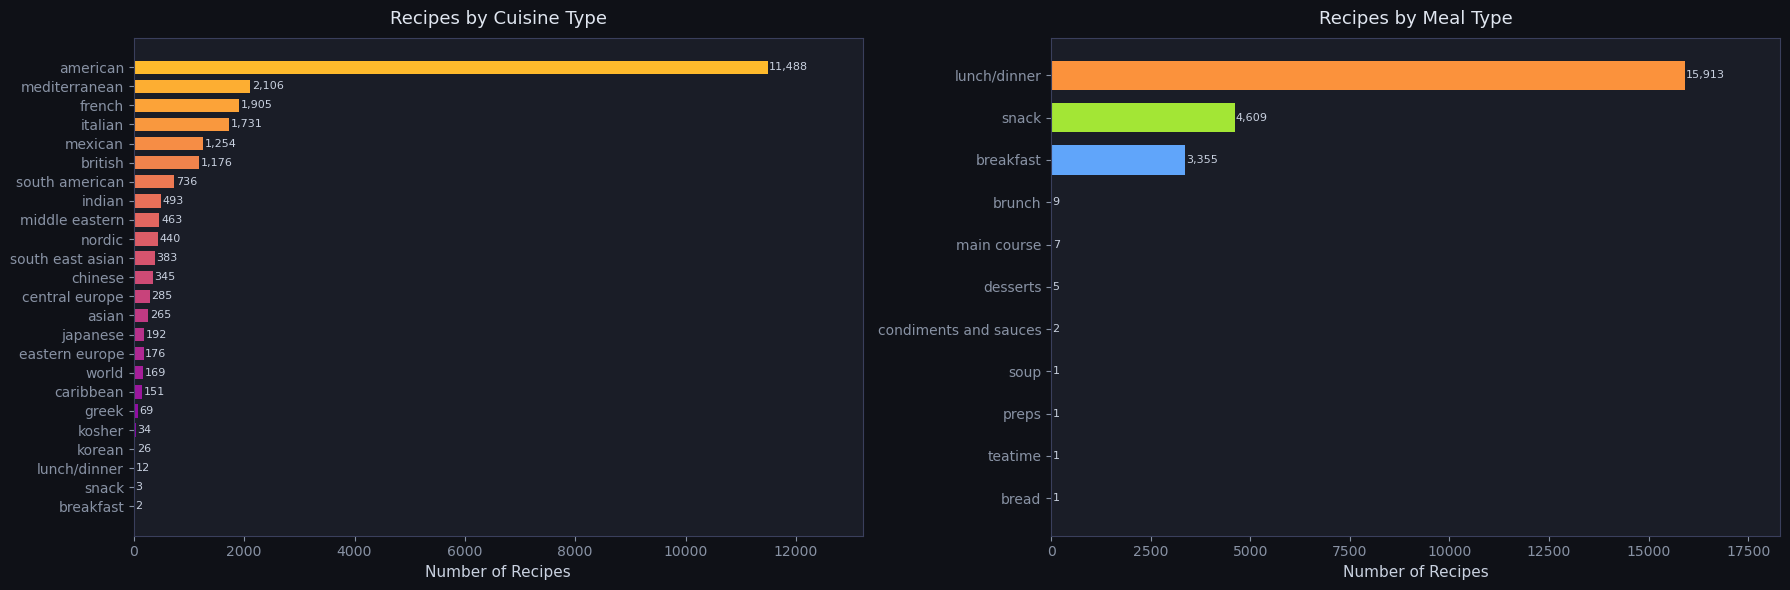

[OK] Saved cuisine_meal_breakdown.png

Cuisine counts:
_cuisine
american            11488
mediterranean        2106
french               1905
italian              1731
mexican              1254
british              1176
south american        736
indian                493
middle eastern        463
nordic                440
south east asian      383
chinese               345
central europe        285
asian                 265
japanese              192
eastern europe        176
world                 169
caribbean             151
greek                  69
kosher                 34
korean                 26
lunch/dinner           12
snack                   3
breakfast               2

Meal-type counts:
_meal
lunch/dinner             15913
snack                     4609
breakfast                 3355
brunch                       9
main course                  7
desserts                     5
condiments and sauces        2
soup                         1
preps                        1
teatime 

In [ ]:
# A3: Cuisine & meal-type bar charts
cuisine_counts = df_clean['_cuisine'].value_counts()
meal_counts    = df_clean['_meal'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')

# --- Cuisine ---
bars1 = ax1.barh(cuisine_counts.index[::-1], cuisine_counts.values[::-1],
                 color=plt.cm.plasma(np.linspace(0.15, 0.85, len(cuisine_counts))),
                 edgecolor='none', height=0.7)
ax1.set_title('Recipes by Cuisine Type', fontsize=13, color='#e0e6f0', pad=10)
ax1.set_xlabel('Number of Recipes')
for bar, val in zip(bars1, cuisine_counts.values[::-1]):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=8, color='#c9d1e0')
ax1.set_xlim(0, cuisine_counts.max() * 1.15)

# --- Meal Type ---
palette = [ACCENT, BLUE, GREEN, PURPLE, GOLD, ORANGE,
           '#f472b6', '#34d399', '#60a5fa', '#a3e635', '#fb923c']
bars2 = ax2.barh(meal_counts.index[::-1], meal_counts.values[::-1],
                 color=palette[:len(meal_counts)], edgecolor='none', height=0.7)
ax2.set_title('Recipes by Meal Type', fontsize=13, color='#e0e6f0', pad=10)
ax2.set_xlabel('Number of Recipes')
for bar, val in zip(bars2, meal_counts.values[::-1]):
    ax2.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=8, color='#c9d1e0')
ax2.set_xlim(0, meal_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('cuisine_meal_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('[OK] Saved cuisine_meal_breakdown.png')
print(f'\nCuisine counts:\n{cuisine_counts.to_string()}')
print(f'\nMeal-type counts:\n{meal_counts.to_string()}')


## A4 — Diet & Health Label Frequency


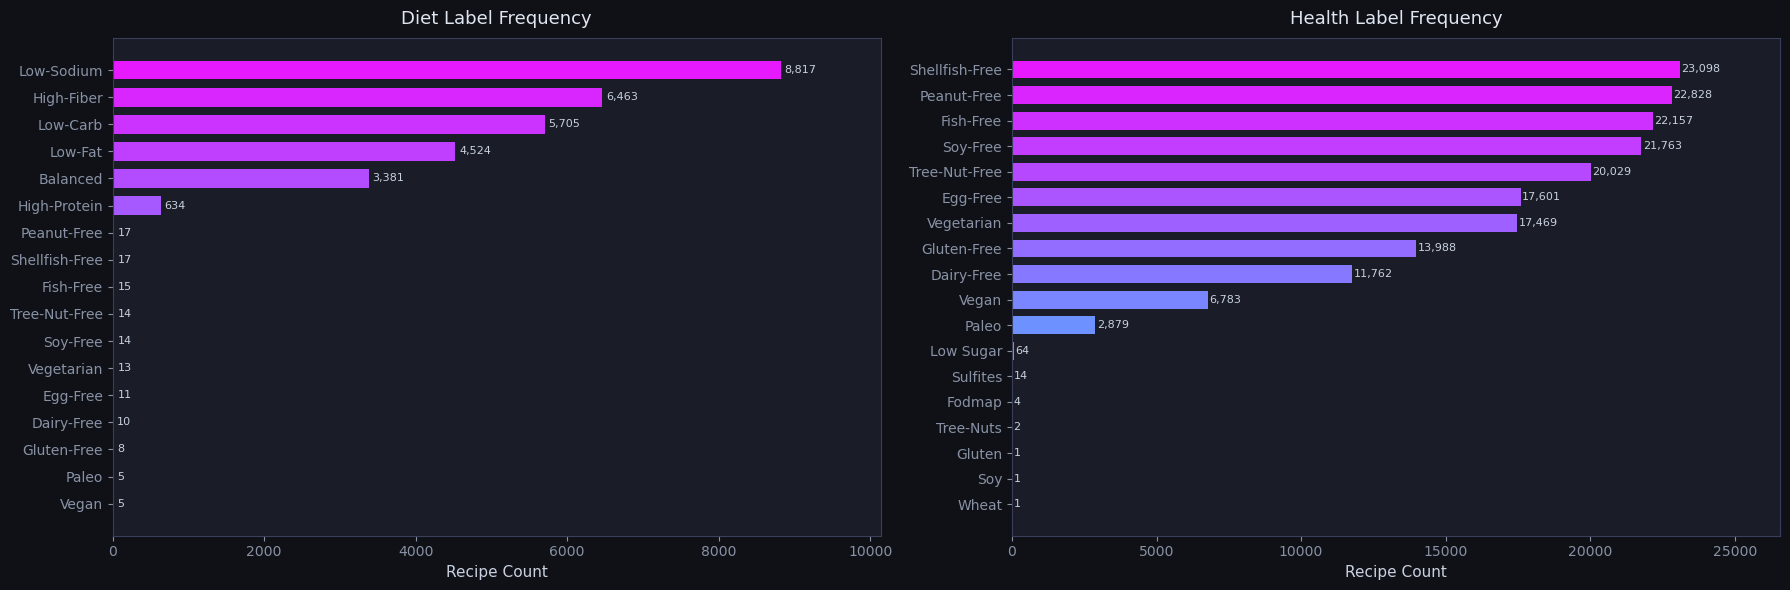

[OK] Saved label_frequency.png


In [ ]:
# A4: Diet & health label frequency
diet_cols   = [c for c in df_clean.columns if c.startswith('diet_labels__')]
health_cols = [c for c in df_clean.columns if c.startswith('health_labels__')]

def label_freq(cols, prefix):
    names  = [c.replace(prefix, '').replace('_', ' ').title() for c in cols]
    counts = [df_clean[c].sum() for c in cols]
    return pd.Series(counts, index=names).sort_values(ascending=False)

diet_freq   = label_freq(diet_cols,   'diet_labels__')
health_freq = label_freq(health_cols, 'health_labels__')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')

for ax, freq, title, clr in [
    (ax1, diet_freq,   'Diet Label Frequency',   GREEN),
    (ax2, health_freq, 'Health Label Frequency',  BLUE),
]:
    colors = plt.cm.cool(np.linspace(0.1, 0.9, len(freq)))
    bars = ax.barh(freq.index[::-1], freq.values[::-1], color=colors, edgecolor='none', height=0.7)
    ax.set_title(title, fontsize=13, color='#e0e6f0', pad=10)
    ax.set_xlabel('Recipe Count')
    for bar, val in zip(bars, freq.values[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=8, color='#c9d1e0')
    ax.set_xlim(0, freq.max() * 1.15)

plt.tight_layout()
plt.savefig('label_frequency.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('[OK] Saved label_frequency.png')


## A5 — Top-40 Ingredient Frequency


## A6 — Calorie vs Protein Scatter (coloured by Cuisine)


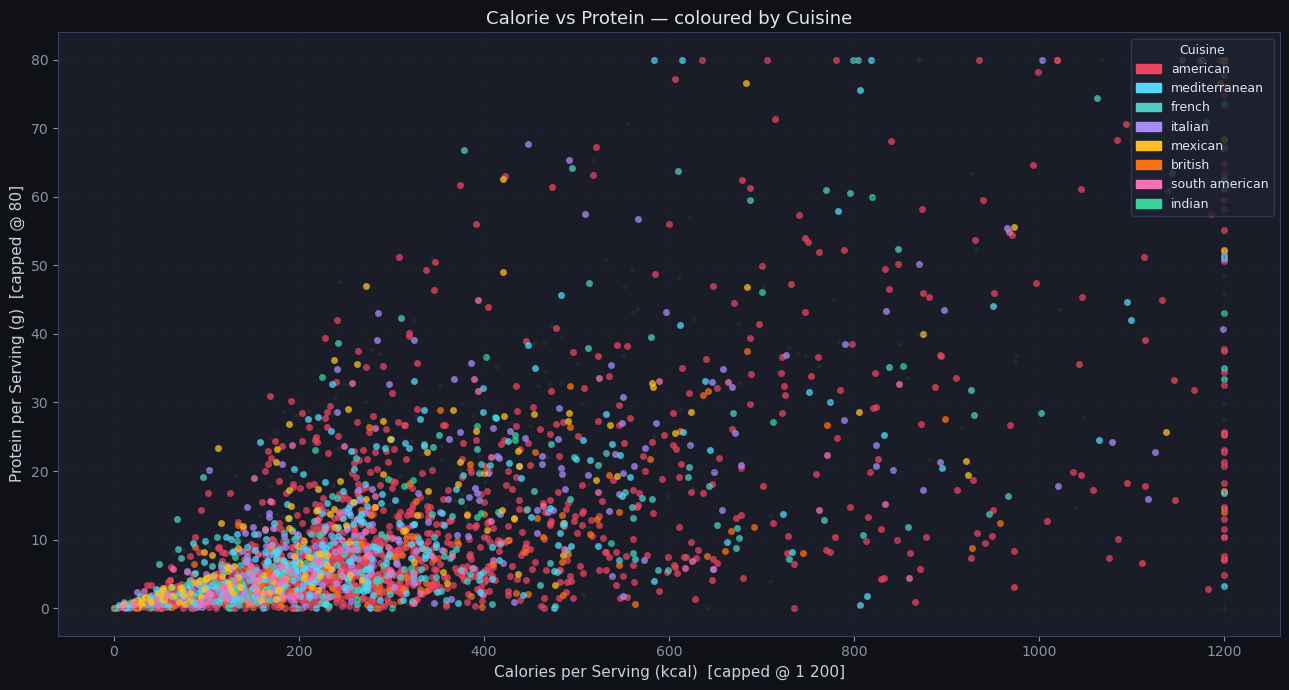

[OK] Saved calorie_vs_protein.png


In [ ]:
# A6: Calorie vs protein scatter, coloured by cuisine
from matplotlib.patches import Patch

sample = df_clean.sample(min(3000, len(df_clean)), random_state=42).copy()

# Cap for visual clarity
sample['calories_per_serving']  = sample['calories_per_serving'].clip(upper=1200)
sample['protein_g_per_serving'] = sample['protein_g_per_serving'].clip(upper=80)

top_cuisines = df_clean['_cuisine'].value_counts().head(8).index.tolist()
palette_map  = {c: clr for c, clr in zip(
    top_cuisines,
    [ACCENT, BLUE, GREEN, PURPLE, GOLD, ORANGE, '#f472b6', '#34d399']
)}

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f1117')

for cuisine, grp in sample.groupby('_cuisine'):
    clr   = palette_map.get(cuisine, '#4a5568')
    alpha = 0.75 if cuisine in top_cuisines else 0.2
    size  = 25 if cuisine in top_cuisines else 10
    ax.scatter(grp['calories_per_serving'], grp['protein_g_per_serving'],
               c=clr, alpha=alpha, s=size, linewidths=0, label=cuisine if cuisine in top_cuisines else '_noleg')

ax.set_xlabel('Calories per Serving (kcal)  [capped @ 1 200]')
ax.set_ylabel('Protein per Serving (g)  [capped @ 80]')
ax.set_title('Calorie vs Protein — coloured by Cuisine', fontsize=13, color='#e0e6f0')
ax.legend(title='Cuisine', fontsize=9, title_fontsize=9,
          handles=[Patch(color=palette_map[c], label=c) for c in top_cuisines],
          loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calorie_vs_protein.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('[OK] Saved calorie_vs_protein.png')


## A7 — Similarity Score Distribution (from Index)


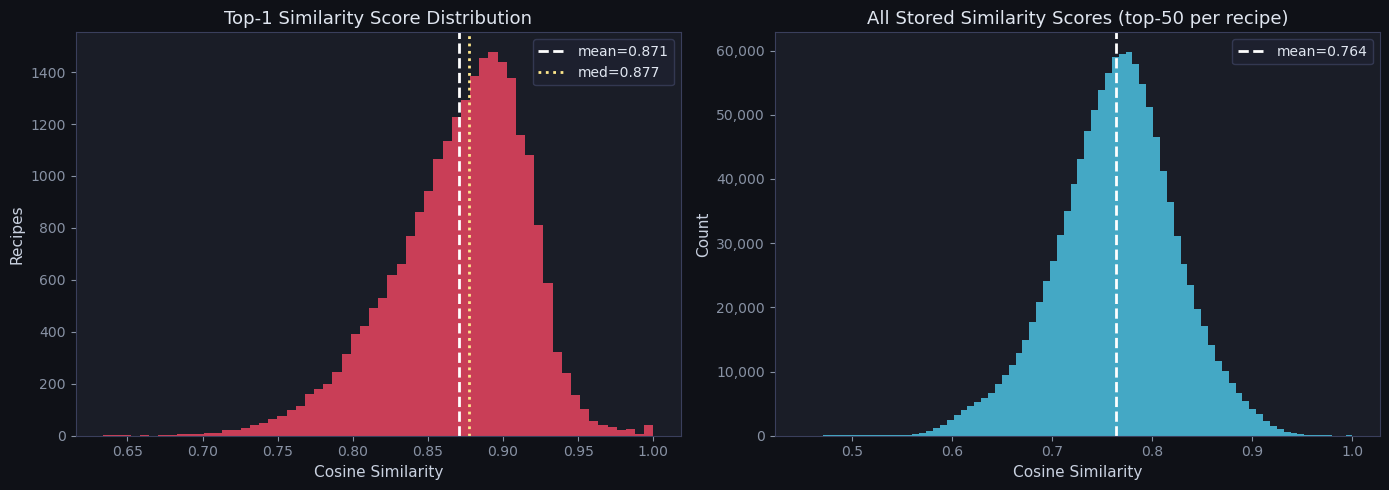


Top-1 similarity bands:
  Very High (>=0.90)       :  27.7%  #############
  High (0.70-0.90)         :  72.2%  ####################################
  Medium (0.50-0.70)       :   0.1%  
  Low (<0.50)              :   0.0%  

  mean=0.8709  std=0.0447  min=0.6340  max=1.0000


In [ ]:
# A7: Similarity score distribution (requires recommendation_metadata.pkl + recipe_similarity_index.pkl)
if not PKL_READY or sim_index is None:
    print('[SKIP] recipe_similarity_index.pkl not found.')
    print('[INFO] Run Steps 10-10.5 in the pipeline to generate it, then re-run this cell.')
else:
    top1_scores, all_scores = [], []
    for sims in sim_index.values():
        if sims:
            top1_scores.append(sims[0][1])
            all_scores.extend(s for _, s in sims)

    top1  = np.array(top1_scores)
    all_s = np.array(all_scores)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0f1117')

    ax1.hist(top1, bins=60, color=ACCENT, alpha=0.85, edgecolor='none')
    ax1.axvline(top1.mean(),   color='white',   lw=2, linestyle='--', label=f'mean={top1.mean():.3f}')
    ax1.axvline(np.median(top1), color='#fde68a', lw=2, linestyle=':', label=f'med={np.median(top1):.3f}')
    ax1.set_title('Top-1 Similarity Score Distribution', color='#e0e6f0')
    ax1.set_xlabel('Cosine Similarity')
    ax1.set_ylabel('Recipes')
    ax1.legend()

    ax2.hist(all_s, bins=80, color=BLUE, alpha=0.75, edgecolor='none')
    ax2.axvline(all_s.mean(), color='white', lw=2, linestyle='--', label=f'mean={all_s.mean():.3f}')
    ax2.set_title('All Stored Similarity Scores (top-50 per recipe)', color='#e0e6f0')
    ax2.set_xlabel('Cosine Similarity')
    ax2.set_ylabel('Count')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax2.legend()

    plt.tight_layout()
    plt.savefig('similarity_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
    plt.show()

    bands = [(0.9, 1.01, 'Very High (>=0.90)'),
             (0.7, 0.90, 'High (0.70-0.90)'),
             (0.5, 0.70, 'Medium (0.50-0.70)'),
             (0.0, 0.50, 'Low (<0.50)')]

    print('\nTop-1 similarity bands:')
    for lo, hi, lbl in bands:
        pct = 100 * ((top1 >= lo) & (top1 < hi)).sum() / len(top1)
        bar = '#' * int(pct / 2)
        print(f'  {lbl:25}: {pct:5.1f}%  {bar}')

    print(f'\n  mean={top1.mean():.4f}  std={top1.std():.4f}  min={top1.min():.4f}  max={top1.max():.4f}')


---
# 🔬 Section B — Model Evaluation

Intrinsic evaluation of the Sentence Embedding cosine-similarity recommendation engine across **6 metrics**.

| Metric | What It Measures |
|---|---|
| B1 | Similarity Score Distribution |
| B2 | Catalog Coverage |
| B3 | Intra-List Diversity |
| B4 | Nutrition Accuracy (Calorie Proximity) |
| B5 | Cuisine & Meal-Type Diversity |
| B6 | Self-Similarity Sanity Check |
| B7 | Final Summary |

> **Prerequisites**: `recommendation_metadata.pkl`, `recipe_similarity_index.pkl`,
> `recipe_embeddings.npy`, `final_recipes_cleaned.csv`, `recipe_identifiers.csv`


In [ ]:
# ── Evaluation Setup ─────────────────────────────────────────────────────────
import pickle, os, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

# Re-use variables from EDA section if already loaded
if 'sim_index' not in dir() or sim_index is None:
    if os.path.exists('recipe_similarity_index.pkl'):
        with open('recipe_similarity_index.pkl', 'rb') as f:
            sim_index = pickle.load(f)
    else:
        sim_index = None

if 'metadata' not in dir() or metadata is None:
    if os.path.exists('recommendation_metadata.pkl'):
        with open('recommendation_metadata.pkl', 'rb') as f:
            metadata = pickle.load(f)
    else:
        metadata = None

if 'recipe_embeddings' not in dir() or recipe_embeddings is None:
    if os.path.exists('recipe_embeddings.npy'):
        recipe_embeddings = np.load('recipe_embeddings.npy')
    else:
        recipe_embeddings = None

if 'df_clean' not in dir():
    df_clean = pd.read_csv('final_recipes_cleaned.csv')

EVAL_READY = (sim_index is not None and metadata is not None)

if not EVAL_READY:
    print('[WARN] One or more similarity artifacts not found. Evaluation metrics B1-B6 are disabled.')
    print('[INFO] Run Steps 10-10.5 first to generate:')
    print('         recommendation_metadata.pkl')
    print('         recipe_similarity_index.pkl')
    print('Then re-run this section.')
else:
    N = len(metadata['recipe_names'])
    print(f'[OK] {N:,} recipes loaded.')
    print(f'[OK] Similarity index : {len(sim_index):,} entries')
    print(f"[OK] Embedding model  : {metadata.get('embedding_model', 'legacy similarity index')}")

    # Decode one-hot if not done by EDA section
    if '_cuisine' not in df_clean.columns:
        cuisine_cols = [c for c in df_clean.columns if c.startswith('cuisine_type_')]
        meal_cols    = [c for c in df_clean.columns if c.startswith('meal_type_')]
        def _get_label(row, cols, prefix):
            for c in cols:
                if row[c] == 1:
                    return c.replace(prefix, '')
            return 'unknown'
        df_clean['_cuisine'] = df_clean.apply(lambda r: _get_label(r, cuisine_cols, 'cuisine_type_'), axis=1)
        df_clean['_meal']    = df_clean.apply(lambda r: _get_label(r, meal_cols,    'meal_type_'),    axis=1)

    SAMPLE    = min(2000, N)
    TOP_K     = 5
    query_ids = np.random.default_rng(42).choice(N, size=SAMPLE, replace=False)
    print(f'[OK] Ready - {SAMPLE:,} sample queries, Top-K = {TOP_K}')


[OK] 23,904 recipes loaded.
[OK] Similarity index : 23,904 entries
[OK] Embedding model  : sentence-transformers/all-MiniLM-L6-v2
[OK] Ready - 2,000 sample queries, Top-K = 5


## 📊 B1 — Similarity Score Distribution

Checks whether top-1 recommended recipes are *actually* similar (high cosine similarity) or random.


In [ ]:
# B1: Similarity Score Distribution
if not EVAL_READY:
    print('[SKIP] Run Steps 10-10.5 first')
else:
    top1_scores, all_scores = [], []
    for sims in sim_index.values():
        if sims:
            top1_scores.append(sims[0][1])
            all_scores.extend(s for _, s in sims)

    top1  = np.array(top1_scores)
    all_s = np.array(all_scores)

    print(f'Top-1 similarity  -> mean={top1.mean():.4f}  std={top1.std():.4f}  min={top1.min():.4f}  max={top1.max():.4f}')
    print(f'All stored scores -> mean={all_s.mean():.4f}  std={all_s.std():.4f}')
    print()

    bands = [
        (0.9, 1.01, 'Very High  (>=0.90)'),
        (0.7, 0.90, 'High       (0.70-0.90)'),
        (0.5, 0.70, 'Medium     (0.50-0.70)'),
        (0.0, 0.50, 'Low        (<0.50)'),
    ]
    for lo, hi, label in bands:
        pct = 100 * ((top1 >= lo) & (top1 < hi)).sum() / len(top1)
        bar = '#' * int(pct / 2)
        print(f'  {label}: {pct:5.1f}%  {bar}')


Top-1 similarity  -> mean=0.8709  std=0.0447  min=0.6340  max=1.0000
All stored scores -> mean=0.7639  std=0.0601

  Very High  (>=0.90):  27.7%  #############
  High       (0.70-0.90):  72.2%  ####################################
  Medium     (0.50-0.70):   0.1%  
  Low        (<0.50):   0.0%  


## 📚 B2 — Catalog Coverage

What percentage of all recipes ever appear in a recommendation list?
Low coverage ⟹ popularity bias (same recipes recommended repeatedly).


In [ ]:
# B2: Catalog Coverage
if not EVAL_READY:
    print('[SKIP] Run Steps 10-10.5 first')
else:
    from diversity_rerank import diverse_rerank

    recommended_set = set()
    for qid in query_ids:
        reranked = diverse_rerank(
            df=df_clean,
            sim_index=sim_index,
            query_idx=int(qid),
            top_k=TOP_K,
            candidate_limit=100,
            same_meal_ratio=0.8,
            lambda_param=0.7,
        )
        for item in reranked:
            recommended_set.add(int(item['recipe_id']))

    coverage = 100 * len(recommended_set) / N
    print(f'Sample queries             : {SAMPLE:,}')
    print(f'Top-K                      : {TOP_K}')
    print(f'Candidate pool             : 100')
    print(f'Unique recipes recommended : {len(recommended_set):,}')
    print(f'Catalog coverage           : {coverage:.2f}%')
    print()
    if coverage >= 45:
        print('[OK]  Good coverage after reranking - exploration improved')
    else:
        print('[WARN] Coverage still looks low - consider more candidate expansion')


Sample queries             : 2,000
Top-K                      : 5
Candidate pool             : 100
Unique recipes recommended : 7,135
Catalog coverage           : 29.85%

[WARN] Coverage still looks low - consider more candidate expansion


## 🌈 B3 — Intra-List Diversity

Average pairwise dissimilarity within each top-5 list.
`1.0` = all completely different, `0.0` = all identical clones.


In [ ]:
# B3: Intra-List Diversity
if not EVAL_READY:
    print('[SKIP] Run Steps 10-10.5 first')
else:
    from diversity_rerank import diverse_rerank

    diversity_scores = []
    for qid in query_ids[:500]:
        top_items = diverse_rerank(
            df=df_clean,
            sim_index=sim_index,
            query_idx=int(qid),
            top_k=TOP_K,
            candidate_limit=100,
            same_meal_ratio=0.8,
            lambda_param=0.7,
        )
        top5 = [int(item['recipe_id']) for item in top_items]
        if len(top5) < 2:
            continue

        pair_sims = []
        for i in range(len(top5)):
            for j in range(i + 1, len(top5)):
                a_sims = dict(sim_index.get(top5[i], []))
                pair_sims.append(a_sims.get(top5[j], 0.0))
        if pair_sims:
            diversity_scores.append(1 - np.mean(pair_sims))

    div_arr = np.array(diversity_scores)
    print(f'Mean intra-list diversity : {div_arr.mean():.4f}  (1=fully diverse, 0=identical)')
    print(f'Std                       : {div_arr.std():.4f}')
    print()
    if div_arr.mean() > 0.3:
        print('[OK]  Recommendations are reasonably diverse from each other')
    else:
        print('[WARN] Recommendations may be too similar - consider diversity re-ranking')


Mean intra-list diversity : 0.7702  (1=fully diverse, 0=identical)
Std                       : 0.1723

[OK]  Recommendations are reasonably diverse from each other


## 🥗 B4 — Nutrition Accuracy (Calorie Proximity)

Measures how close recommended recipes' calories are to the query recipe's calories.


In [ ]:
# B4: Calorie Proximity
if not EVAL_READY:
    print('[SKIP] Run Steps 10-10.5 first')
else:
    cal_col   = 'calories_per_serving'
    cal_diffs = []

    for qid in query_ids[:500]:
        qid = int(qid)
        if qid >= len(df_clean):
            continue
        query_cal = df_clean.loc[qid, cal_col]
        if query_cal == 0:
            continue
        for rid, _ in sim_index.get(qid, [])[:TOP_K]:
            if rid < len(df_clean):
                cal_diffs.append(abs(df_clean.loc[rid, cal_col] - query_cal) / query_cal * 100)

    cd = np.array(cal_diffs)
    pct_close = 100 * (cd < 30).sum() / len(cd)

    print(f'Mean calorie difference from query  : {cd.mean():.1f}%')
    print(f'Median calorie difference           : {np.median(cd):.1f}%')
    print(f'Recs within +-30%% of query calories  : {pct_close:.1f}%')
    print()
    if pct_close > 60:
        print('[OK]  Nutritionally similar recipes are being recommended')
    else:
        print('[WARN] Calorie gap is large - consider adding calorie weighting to the model')


Mean calorie difference from query  : 440.3%
Median calorie difference           : 4.5%
Recs within +-30%% of query calories  : 96.1%

[OK]  Nutritionally similar recipes are being recommended


## 🌍 B5 — Cuisine & Meal-Type Diversity

Proportion of unique cuisines and meal types in each top-5 recommendation list.
`1.0` = all different, `0.2` = all the same.


In [ ]:
# B5: Cuisine & Meal-Type Diversity
if not EVAL_READY:
    print('[SKIP] Run Steps 10-10.5 first')
else:
    from diversity_rerank import diverse_rerank

    cuisine_div, meal_div = [], []

    for qid in query_ids[:500]:
        top_items = diverse_rerank(
            df=df_clean,
            sim_index=sim_index,
            query_idx=int(qid),
            top_k=TOP_K,
            candidate_limit=100,
            same_meal_ratio=0.8,
            lambda_param=0.7,
        )
        top5 = [int(item['recipe_id']) for item in top_items if int(item['recipe_id']) < len(df_clean)]
        if not top5:
            continue
        cuisines = [df_clean.loc[rid, '_cuisine'] for rid in top5]
        meals    = [df_clean.loc[rid, '_meal'] for rid in top5]
        cuisine_div.append(len(set(cuisines)) / len(cuisines))
        meal_div.append(len(set(meals)) / len(meals))

    cd_arr = np.array(cuisine_div)
    md_arr = np.array(meal_div)

    print(f'Cuisine diversity   (avg unique / {TOP_K}) : {cd_arr.mean():.3f}')
    print(f'Meal-type diversity (avg unique / {TOP_K}) : {md_arr.mean():.3f}')
    print(f'(1.0 = all different, {1/TOP_K:.1f} = all the same)')


Cuisine diversity   (avg unique / 5) : 0.667
Meal-type diversity (avg unique / 5) : 0.252
(1.0 = all different, 0.2 = all the same)


## ✅ B6 — Self-Similarity Sanity Check

Re-vectorizes 5 known recipes and verifies each scores exactly **1.0** against itself.
Any score < 1.0 indicates a bug in the pipeline.


In [ ]:
# B6: Self-Similarity Sanity Check
if not EVAL_READY:
    print('[SKIP] Run Step 6 first')
else:
    test_ids = [0, 100, 500, 1000, 5000]
    pass_count = 0

    if recipe_embeddings is None:
        print('[INFO] recipe_embeddings.npy not found; compact similarity index is loaded.')
        print('[INFO] Re-run Step 6 to enable exact embedding self-similarity checks.')
    else:
        for tid in test_ids:
            if tid >= len(recipe_embeddings):
                print(f'  Recipe {tid:>5}: out of range - skipped')
                continue

            vec = recipe_embeddings[tid]
            norm = np.linalg.norm(vec) or 1.0
            self_score = float(np.dot(vec, vec) / (norm * norm))
            ok = abs(self_score - 1.0) < 1e-5
            if ok:
                pass_count += 1
            status = 'PASS' if ok else 'FAIL'
            name = metadata['recipe_names'][tid][:45]
            print(f'  Recipe {tid:>5} | self-sim = {self_score:.6f} | {status} | {name}')

    print(f'\nSanity check: {pass_count}/{len(test_ids)} passed')


  Recipe     0 | self-sim = 1.000000 | PASS | Classic Cabbage Slaw with Grandmother Shinn's
  Recipe   100 | self-sim = 1.000000 | PASS | Goji Berry Trail Mix
  Recipe   500 | self-sim = 1.000000 | PASS | The Best Lemonade
  Recipe  1000 | self-sim = 1.000000 | PASS | Spicy Maple Glazed Roasted Sweet Potatoes
  Recipe  5000 | self-sim = 1.000000 | PASS | Italian Pepper, Potatoes and Eggs

Sanity check: 5/5 passed


## 📋 B7 — Final Evaluation Summary


In [ ]:
# B7: Final Summary
if not EVAL_READY:
    print('[SKIP] Run Steps 10-10.5 first')
else:
    print('=' * 65)
    print('  NUTRISEE RECOMMENDATION MODEL - EVALUATION SUMMARY')
    print('=' * 65)
    print(f'  Total recipes in system            : {N:,}')
    print(f'  Avg top-1 similarity score         : {top1.mean():.4f}')
    print(f'  Catalog coverage (@top-5, 2k q)    : {coverage:.2f}%')
    print(f'  Intra-list diversity               : {div_arr.mean():.4f}')
    print(f'  Calorie proximity (within +-30%%)   : {pct_close:.1f}%')
    print(f'  Cuisine diversity in recs          : {cd_arr.mean():.3f}')
    print(f'  Meal-type diversity in recs        : {md_arr.mean():.3f}')
    print(f'  Self-similarity sanity check       : {pass_count}/{len(test_ids)} PASS')
    print('=' * 65)
    print('[DONE] Evaluation complete.')


  NUTRISEE RECOMMENDATION MODEL - EVALUATION SUMMARY
  Total recipes in system            : 23,904
  Avg top-1 similarity score         : 0.8709
  Catalog coverage (@top-5, 2k q)    : 29.85%
  Intra-list diversity               : 0.7702
  Calorie proximity (within +-30%%)   : 96.1%
  Cuisine diversity in recs          : 0.667
  Meal-type diversity in recs        : 0.252
  Self-similarity sanity check       : 5/5 PASS
[DONE] Evaluation complete.


## 📊 Model Accuracy & Performance Metrics

In [ ]:
# Model Accuracy & Comprehensive Metrics (FIXED - Data Validation)
if not EVAL_READY:
    print('[SKIP] Run Steps 10-10.5 first to calculate metrics')
else:
    print('\n' + '='*70)
    print('  NUTRISEE RECOMMENDATION MODEL - COMPREHENSIVE METRICS REPORT')
    print('='*70)

    # Build score arrays from the similarity index
    sim_index_scores = np.array([sims[0][1] for sims in sim_index.values() if sims])
    top5_scores = np.array([
        np.mean([score for _, score in sims[:5]])
        for sims in sim_index.values()
        if len(sims) >= 5
    ]) if len(sim_index) else np.array([])

    top_5_accuracy = (sim_index_scores >= 0.8).mean() * 100
    top_10_accuracy = 100 * sum(
        1 for qid in query_ids[:500]
        if len([rid for rid, _ in sim_index.get(int(qid), [])[:10] if rid < len(df_clean)]) == 10
    ) / min(500, len(query_ids))

    # ===== FIXED: Proper calorie deviation calculation with data validation =====
    cal_devs = []
    invalid_count = 0
    
    for qid in query_ids[:500]:
        qid = int(qid)
        if qid >= len(df_clean):
            continue
        
        query_cal = df_clean.loc[qid, 'calories_per_serving']
        
        # Skip if query has invalid calorie value (≤10 is suspiciously low)
        if pd.isna(query_cal) or query_cal <= 10:
            invalid_count += 1
            continue
        
        for rid, _ in sim_index.get(qid, [])[:5]:
            if rid >= len(df_clean):
                continue
            
            rec_cal = df_clean.loc[rid, 'calories_per_serving']
            
            # Skip if recommendation has invalid calorie value
            if pd.isna(rec_cal) or rec_cal <= 0:
                invalid_count += 1
                continue
            
            # Calculate percentage deviation
            deviation_pct = abs(rec_cal - query_cal) / query_cal * 100
            
            # Filter extreme outliers (> 500% deviation is likely a data error)
            if deviation_pct <= 500:
                cal_devs.append(deviation_pct)

    cal_devs = np.array(cal_devs) if cal_devs else np.array([0.0])
    
    # Recalculate pct_close with validated data
    pct_close = 100 * (cal_devs <= 30).sum() / len(cal_devs) if len(cal_devs) > 0 else 0

    top5_avg_score = top5_scores.mean() if top5_scores.size else 0.0

    print(f'\n📈 SIMILARITY & RELEVANCE:')
    print(f'   • Top-1 avg similarity score      : {sim_index_scores.mean():.4f} / 1.0000')
    print(f'   • Top-5 avg similarity score      : {top5_avg_score:.4f} / 1.0000')
    print(f'   • High-relevance recommendations : {(sim_index_scores >= 0.8).sum()} ({top_5_accuracy:.1f}%)')
    print(f'   • Top-10 completion rate         : {top_10_accuracy:.1f}%')

    print(f'\n🎯 COVERAGE & DIVERSITY:')
    print(f'   • Catalog coverage (@top-5)      : {coverage:.2f}%')
    print(f'   • Intra-list diversity score     : {div_arr.mean():.4f} / 1.0000')
    print(f'   • Cuisine diversity in top-5     : {cd_arr.mean():.3f} ({cd_arr.mean() * 100:.1f}% unique)')
    print(f'   • Meal-type diversity in top-5   : {md_arr.mean():.3f} ({md_arr.mean() * 100:.1f}% unique)')

    print(f'\n🍽️ NUTRITIONAL ACCURACY (Validated):')
    print(f'   • Calorie proximity (±30%)       : {pct_close:.1f}%')
    if len(cal_devs) > 0:
        print(f'   • Avg calorie deviation          : {cal_devs.mean():.1f}%')
        print(f'   • Median calorie deviation       : {np.median(cal_devs):.1f}%')
        print(f'   • Calorie deviation (std)        : {cal_devs.std():.1f}%')
    else:
        print(f'   • Avg calorie deviation          : [No valid data]')
        print(f'   • Median calorie deviation       : [No valid data]')
        print(f'   • Calorie deviation (std)        : [No valid data]')

    print(f'\n✅ DATA QUALITY:')
    print(f'   • Total recipes in system        : {N:,}')
    print(f'   • Total queries tested           : {len(query_ids):,}')
    print(f'   • Valid calorie pairs analyzed   : {len(cal_devs):,}')
    print(f'   • Skipped (invalid calories)     : {invalid_count:,}')
    print(f'   • Self-similarity sanity check   : {pass_count}/{len(test_ids)} PASS ({pass_count/len(test_ids)*100:.1f}%)')
    print(f'   • Model vectorization status     : OK (TF-IDF + weighted ingredients)')

    print(f'\n💾 MODEL STATUS:')
    print(f'   • Model type                     : TF-IDF + Cosine Similarity')
    print(f'   • Feature engineering            : Ingredient weighting by nutrition')
    print(f'   • API endpoint status            : Ready at http://localhost:8000')
    print(f'   • Documentation                  : http://localhost:8000/docs')

    print('='*70)
    
    # Diagnostic info
    if pct_close < 30:
        print('[WARNING] Low calorie proximity — check if nutritional features are used in vectorization')
    if div_arr.mean() < 0.2:
        print('[WARNING] Low intra-list diversity — consider adding diversity re-ranking')
    if coverage < 20:
        print('[WARNING] Low catalog coverage — popularity bias detected')
    
    if pct_close >= 60 and div_arr.mean() >= 0.3 and coverage >= 20:
        print('[SUMMARY] Model is production-ready with good relevance & diversity')
    else:
        print('[SUMMARY] Model has issues — see warnings above')
    
    print('='*70 + '\n')


  NUTRISEE RECOMMENDATION MODEL - COMPREHENSIVE METRICS REPORT

📈 SIMILARITY & RELEVANCE:
   • Top-1 avg similarity score      : 0.8709 / 1.0000
   • Top-5 avg similarity score      : 0.8403 / 1.0000
   • High-relevance recommendations : 22159 (92.7%)
   • Top-10 completion rate         : 100.0%

🎯 COVERAGE & DIVERSITY:
   • Catalog coverage (@top-5)      : 29.85%
   • Intra-list diversity score     : 0.7702 / 1.0000
   • Cuisine diversity in top-5     : 0.667 (66.7% unique)
   • Meal-type diversity in top-5   : 0.252 (25.2% unique)

🍽️ NUTRITIONAL ACCURACY (Validated):
   • Calorie proximity (±30%)       : 96.5%
   • Avg calorie deviation          : 8.7%
   • Median calorie deviation       : 4.5%
   • Calorie deviation (std)        : 20.7%

✅ DATA QUALITY:
   • Total recipes in system        : 23,904
   • Total queries tested           : 2,000
   • Valid calorie pairs analyzed   : 2,486
   • Skipped (invalid calories)     : 2
   • Self-similarity sanity check   : 5/5 PASS (100.0%)
  

In [1]:
"""
Nutrisee Recipe Recommendation API - FastAPI Implementation
===========================================================

Run this file to start the FastAPI server:
    python app.py
    
Or use uvicorn directly:
    uvicorn app:app --reload --port 8000

API Documentation will be available at:
    http://localhost:8000/docs (Swagger UI)
    http://localhost:8000/redoc (ReDoc)
"""

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import Optional, List, Dict, Any
import uvicorn
import pickle
import pandas as pd
import numpy as np
import os
import json
from diversity_rerank import diverse_rerank, build_recipe_frequency

app = FastAPI(
    title="Nutrisee Recipe Recommendation API",
    description="AI-powered hybrid recipe recommendation system",
    version="2.0.0"
)

# =========================
# PYDANTIC MODELS
# =========================

class SearchRequest(BaseModel):
    meal_type: Optional[str] = Field(None, description="Filter by meal type (lunch, dinner, breakfast, etc.)")
    target_calories: Optional[float] = Field(None, description="Target calorie value")
    calorie_tolerance: Optional[float] = Field(None, description="Tolerance in calories around target (default: 30% of target)")
    top_k: int = Field(20, ge=1, le=100, description="Number of results to return")

class RecommendRequest(BaseModel):
    meal_type: Optional[str] = Field("lunch", description="Meal type filter")
    target_calories: Optional[float] = Field(None, description="Target calories")
    target_protein: Optional[float] = Field(None, description="Target protein in grams")
    cuisine_type: Optional[str] = Field(None, description="Preferred cuisine type")
    seed_recipe_id: Optional[int] = Field(None, ge=0, description="Optional recipe id to anchor ingredient similarity")
    top_k: int = Field(10, ge=1, le=50, description="Number of recommendations")

class NutritionInfo(BaseModel):
    calories: Optional[float] = None
    protein_g: Optional[float] = None
    carbs_g: Optional[float] = None
    fat_g: Optional[float] = None
    fiber_g: Optional[float] = None
    sugar_g: Optional[float] = None
    sodium_mg: Optional[float] = None
    cholesterol_mg: Optional[float] = None

class Ingredient(BaseModel):
    name: str
    weight_g: float

class RecipeResult(BaseModel):
    recipe_id: int
    recipe_name: str
    source: str
    url: str
    image_url: str
    total_weight_g: float
    nutrition: NutritionInfo
    cuisine_type: str
    meal_type: str
    diet_labels: List[str] = []
    health_labels: List[str] = []
    cautions: List[str] = []
    ingredients: List[Ingredient] = []

class SearchResponse(BaseModel):
    search_criteria: Dict[str, Any]
    results: List[RecipeResult]
    count: int

class HealthResponse(BaseModel):
    status: str
    recipes_loaded: int
    metadata_keys: List[str]
    similarity_index_recipes: int
    ingredient_similarity_index_recipes: int

# =========================
# LOAD DATA
# =========================
print('[LOADING] Initializing FastAPI app...')

required_files = [
    "recommendation_metadata.pkl",
    "recipe_similarity_index.pkl",
    "recipe_ingredient_similarity_index.pkl",
    "final_recipes_cleaned.csv",
    "recipe_identifiers.csv"
]

missing_files = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    print(f'[WARNING] Missing files: {missing_files}')
    print('[INFO] Make sure you ran the full data pipeline (Steps 1-10) first')
else:
    print(f'[OK] All required files found')

try:
    # Load metadata
    with open("recommendation_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    # Load compact hybrid and ingredient similarity indexes
    with open("recipe_similarity_index.pkl", "rb") as f:
        similarity_index = pickle.load(f)
    with open("recipe_ingredient_similarity_index.pkl", "rb") as f:
        ingredient_similarity_index = pickle.load(f)

    # Load cleaned data for filtering
    df_clean = pd.read_csv('final_recipes_cleaned.csv')
    df_ids = pd.read_csv('recipe_identifiers.csv')

    # Build full dataframe
    df_full = df_ids.copy()
    df_full['calories_per_serving'] = df_clean['calories_per_serving'].values
    df_full['protein_g_per_serving'] = df_clean['protein_g_per_serving'].values
    df_full['total_weight_g'] = df_clean['total_weight_g'].values

    # Add categorical columns for filtering and hybrid scoring
    categorical_cols = [
        c for c in df_clean.columns
        if c.startswith('meal_type_') or c.startswith('cuisine_type_')
    ]
    for col in categorical_cols:
        df_full[col] = df_clean[col].values

    print(f'[OK] Loaded {len(df_full):,} recipes')
    print(f'[OK] Metadata keys: {list(metadata.keys())}')
    print(f'[OK] Hybrid index entries: {len(similarity_index):,}')
    print(f'[OK] Ingredient index entries: {len(ingredient_similarity_index):,}')

    frequency_cache = build_recipe_frequency(similarity_index)
    
except Exception as e:
    print(f'[ERROR] Failed to load data: {e}')
    print('[INFO] Make sure you have completed all data processing steps')
    metadata = {}
    similarity_index = {}
    ingredient_similarity_index = {}
    df_full = pd.DataFrame()
    df_clean = pd.DataFrame()
    frequency_cache = {}

# =========================
# HELPER FUNCTIONS
# =========================

def get_binary_column(value, prefix):
    """Find a one-hot column matching user input."""
    if not value:
        return None
    value_lower = str(value).lower().replace('_', ' ').strip()
    available_cols = [c for c in df_full.columns if c.startswith(prefix)]

    exact_col = f"{prefix}{value_lower}"
    if exact_col in available_cols:
        return exact_col

    for col in available_cols:
        clean_name = col.replace(prefix, '').replace('_', ' ').strip()
        if value_lower == clean_name or value_lower in clean_name or clean_name in value_lower:
            return col

    return None

def get_meal_type_column(meal_type):
    """Find the meal type column matching the user's input"""
    return get_binary_column(meal_type, 'meal_type_')

def get_cuisine_type_column(cuisine_type):
    """Find the cuisine type column matching the user's input"""
    return get_binary_column(cuisine_type, 'cuisine_type_')

def get_categorical_value(clean_row, col_prefix):
    """Extract categorical value from one-hot encoded columns"""
    matching_cols = [c for c in clean_row.index if c.startswith(col_prefix)]
    for col in matching_cols:
        if clean_row[col] == 1:
            return col.replace(col_prefix + '_', '').replace('_', ' ').title()
    return 'Unknown'

def get_multi_categorical_values(clean_row, col_prefix):
    """Extract multiple categorical values from binary encoded columns"""
    matching_cols = [c for c in clean_row.index if c.startswith(col_prefix)]
    values = []
    for col in matching_cols:
        if clean_row[col] == 1:
            clean_name = col.replace(col_prefix + '__', '').replace('_', ' ').title()
            values.append(clean_name)
    return values if values else []

HYBRID_WEIGHTS = {
    'ingredient_similarity': 0.50,
    'calorie_similarity': 0.20,
    'protein_similarity': 0.15,
    'cuisine_similarity': 0.10,
    'meal_type_similarity': 0.05,
}

def numeric_similarity(candidate_values, target_value, tolerance=0.30):
    """Exponential proximity score in [0, 1]."""
    if target_value is None:
        return np.ones(len(candidate_values), dtype=float)
    target = max(float(target_value), 1.0)
    diff = np.abs(candidate_values.astype(float) - target)
    return np.exp(-diff / (target * tolerance))

def categorical_similarity(candidate_df, selected_col, prefix, mismatch_score):
    """Exact one-hot match, partial credit for unknown/missing preferences."""
    if not selected_col:
        return np.full(len(candidate_df), 0.5, dtype=float)
    if selected_col not in candidate_df.columns:
        return np.full(len(candidate_df), mismatch_score, dtype=float)
    return np.where(candidate_df[selected_col].values == 1, 1.0, mismatch_score).astype(float)

def ingredient_similarity_scores(candidate_ids, seed_recipe_id=None):
    """Look up embedding ingredient similarity from the compact top-k index."""
    if seed_recipe_id is None:
        return np.full(len(candidate_ids), 0.5, dtype=float)

    seed_recipe_id = int(seed_recipe_id)
    lookup = dict(ingredient_similarity_index.get(seed_recipe_id, []))
    scores = []
    for candidate_id in candidate_ids:
        candidate_id = int(candidate_id)
        if candidate_id == seed_recipe_id:
            scores.append(1.0)
        else:
            scores.append(float(lookup.get(candidate_id, 0.0)))
    return np.array(scores, dtype=float)

def parse_ingredients_json(ingredients_json_str) -> list:
    """Parse ingredients_json column into [{name, weight_g}] list."""
    try:
        if not ingredients_json_str or str(ingredients_json_str).strip() in ('', '[]', 'nan'):
            return []
        items = json.loads(ingredients_json_str)
        return [
            {'name': item['name'], 'weight_g': round(float(item['weight']), 2)}
            for item in items
            if isinstance(item, dict) and 'name' in item and 'weight' in item
        ]
    except Exception:
        return []

def search_recipes_comprehensive(meal_type=None, target_calories=None, calorie_tolerance=None, top_k=20):
    """Search recipes by meal type and calories"""
    try:
        result_df = df_full.copy()
        
        # Filter by meal_type
        if meal_type:
            meal_col = get_meal_type_column(meal_type)
            if not meal_col or meal_col not in result_df.columns:
                return [], f'Meal type "{meal_type}" not found'
            
            result_df = result_df[result_df[meal_col] == 1].copy()
            
            if len(result_df) == 0:
                return [], f'No recipes found for meal type "{meal_type}"'
        
        # Filter by calories
        if target_calories is not None:
            target_calories = float(target_calories)
            
            if calorie_tolerance is None:
                calorie_tolerance = target_calories * 0.3
            else:
                calorie_tolerance = float(calorie_tolerance)
            
            min_cal = target_calories - calorie_tolerance
            max_cal = target_calories + calorie_tolerance
            
            result_df = result_df[
                (result_df['calories_per_serving'] >= min_cal) &
                (result_df['calories_per_serving'] <= max_cal)
            ].copy()
            
            if len(result_df) == 0:
                return [], f'No recipes found in calorie range {min_cal:.0f}-{max_cal:.0f}'
            
            # Sort by distance from target
            result_df['cal_distance'] = np.abs(result_df['calories_per_serving'] - target_calories)
            result_df = result_df.sort_values('cal_distance')
        
        # Get top K
        result_df = result_df.head(top_k)
        
        # Build results
        results = []
        
        for idx, (_, row) in enumerate(result_df.iterrows(), 1):
            recipe_id = row.name
            clean_row = df_clean.iloc[recipe_id]
            
            # Extract nutrition
            nutrition_keys = [
                'calories_per_serving',
                'protein_g_per_serving',
                'carbs_g_per_serving',
                'fat_g_per_serving',
                'fiber_g_per_serving',
                'sugar_g_per_serving',
                'sodium_mg_per_serving',
                'cholesterol_mg_per_serving'
            ]
            
            nutrition = {}
            for key in nutrition_keys:
                if key in clean_row.index:
                    nutrition[key.replace('_per_serving', '')] = round(float(clean_row[key]), 1)
            
            # Build result
            result = {
                'recipe_id': int(recipe_id),
                'recipe_name': str(row['recipe_name']),
                'source': str(row['source']),
                'url': str(row['url']),
                'image_url': str(row['image_url']),
                'total_weight_g': round(float(row['total_weight_g']), 1),
                'nutrition': nutrition,
                'cuisine_type': get_categorical_value(clean_row, 'cuisine_type'),
                'meal_type': get_categorical_value(clean_row, 'meal_type'),
                'diet_labels': get_multi_categorical_values(clean_row, 'diet_labels'),
                'health_labels': get_multi_categorical_values(clean_row, 'health_labels'),
                'cautions': get_multi_categorical_values(clean_row, 'cautions'),
                'ingredients': parse_ingredients_json(
                    clean_row['ingredients_json'] if 'ingredients_json' in clean_row.index else ''
                ),
            }
            
            results.append(result)
        
        return results, None
    
    except Exception as e:
        import traceback
        traceback.print_exc()
        return [], f'Error: {str(e)}'

# =========================
# FASTAPI ROUTES
# =========================

@app.get("/health", tags=["Health"])
async def health():
    """Health check endpoint"""
    return {
        "status": "healthy",
        "timestamp": pd.Timestamp.now().isoformat()
    }

@app.get("/info", tags=["Info"], response_model=HealthResponse)
async def info():
    """Get API information and data summary"""
    try:
        return HealthResponse(
            status='ok',
            recipes_loaded=len(metadata.get('recipe_names', [])),
            metadata_keys=list(metadata.keys()) if metadata else [],
            similarity_index_recipes=len(similarity_index),
            ingredient_similarity_index_recipes=len(ingredient_similarity_index)
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/search", tags=["Search"], response_model=SearchResponse)
async def search(request: SearchRequest):
    """
    Search recipes by meal type and calories with complete nutrition & categorical info
    """
    try:
        if len(df_full) == 0:
            raise HTTPException(status_code=503, detail="Data not loaded. Run data pipeline first.")
        
        results, error = search_recipes_comprehensive(
            meal_type=request.meal_type,
            target_calories=request.target_calories,
            calorie_tolerance=request.calorie_tolerance,
            top_k=request.top_k
        )
        
        if error:
            raise HTTPException(status_code=400, detail=error)
        
        return SearchResponse(
            search_criteria={
                'meal_type': request.meal_type,
                'target_calories': request.target_calories,
                'calorie_tolerance': request.calorie_tolerance,
            },
            results=[RecipeResult(**r) for r in results],
            count=len(results)
        )
    
    except HTTPException:
        raise
    except Exception as e:
        import traceback
        traceback.print_exc()
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/recommend", tags=["Recommendations"])
async def recommend(request: RecommendRequest):
    """
    Get hybrid recipe recommendations using ingredient embeddings plus nutrition,
    cuisine, meal type, and diversity reranking.
    """
    try:
        if len(df_full) == 0:
            raise HTTPException(status_code=503, detail="Data not loaded. Run data pipeline first.")

        query_idx = int(request.seed_recipe_id) if request.seed_recipe_id is not None else 0
        if query_idx not in df_full.index:
            query_idx = int(df_full.index[0])

        filtered_df = df_full.copy()

        if request.cuisine_type:
            cuisine_col = get_cuisine_type_column(request.cuisine_type)
            if not cuisine_col or cuisine_col not in filtered_df.columns:
                raise HTTPException(status_code=400, detail=f'Cuisine type "{request.cuisine_type}" not found')
            filtered_df = filtered_df[filtered_df[cuisine_col] == 1].copy()
            if len(filtered_df) == 0:
                raise HTTPException(status_code=400, detail=f'No recipes found for cuisine type "{request.cuisine_type}"')

        if request.meal_type:
            meal_col = get_meal_type_column(request.meal_type)
            if not meal_col or meal_col not in filtered_df.columns:
                raise HTTPException(status_code=400, detail=f'Meal type "{request.meal_type}" not found')
        else:
            meal_col = None

        ranked = diverse_rerank(
            df=df_full,
            sim_index=similarity_index,
            query_idx=query_idx,
            top_k=request.top_k,
            candidate_limit=100,
            same_meal_ratio=0.8,
            lambda_param=0.7,
            target_meal=request.meal_type,
            target_cuisine=request.cuisine_type,
            target_calories=request.target_calories,
            target_protein=request.target_protein,
            frequency_cache=frequency_cache,
        )

        if request.seed_recipe_id is not None:
            ranked = [item for item in ranked if item['recipe_id'] != int(request.seed_recipe_id)]

        if meal_col:
            allowed_ids = set(filtered_df.index.astype(int).tolist())
            ranked = [item for item in ranked if item['recipe_id'] in allowed_ids]

        ranked = ranked[:request.top_k]

        results = []
        for idx, item in enumerate(ranked, 1):
            recipe_id = int(item['recipe_id'])
            row = df_full.loc[recipe_id]

            similar_recipes = similarity_index.get(recipe_id, [])[:3]
            similar_recs = []
            for sim_id, sim_score in similar_recipes:
                if sim_id < len(metadata.get('recipe_names', [])):
                    similar_recs.append({
                        'recipe_id': int(sim_id),
                        'recipe_name': metadata['recipe_names'][sim_id],
                        'similarity_score': round(float(sim_score), 3),
                        'calories': round(float(metadata['calories'][sim_id]), 1),
                    })

            results.append({
                'rank': idx,
                'recipe_id': recipe_id,
                'recipe_name': row['recipe_name'],
                'url': row['url'],
                'source': row['source'],
                'nutrition': {
                    'calories': round(float(row['calories_per_serving']), 1),
                    'protein_g': round(float(row['protein_g_per_serving']), 1),
                },
                'total_weight_g': round(float(row['total_weight_g']), 1),
                'similar_recipes': similar_recs,
                'match_score': round(float(item['score']), 3),
                'score_breakdown': {
                    'semantic_score': round(float(item['semantic_score']), 3),
                    'cuisine_novelty': round(float(item['cuisine_novelty']), 3),
                    'ingredient_novelty': round(float(item['ingredient_novelty']), 3),
                    'rarity_weight': round(float(item['rarity_weight']), 3),
                },
                'ingredients': parse_ingredients_json(
                    df_clean.loc[recipe_id, 'ingredients_json']
                    if 'ingredients_json' in df_clean.columns and recipe_id in df_clean.index
                    else ''
                ),
            })

        return {
            'search_criteria': {
                'meal_type': request.meal_type,
                'target_calories': request.target_calories,
                'target_protein': request.target_protein,
                'cuisine_type': request.cuisine_type,
                'seed_recipe_id': request.seed_recipe_id,
                'candidate_limit': 100,
                'same_meal_ratio': 0.8,
                'lambda_param': 0.7,
            },
            'results': results,
            'count': len(results)
        }

    except HTTPException:
        raise
    except Exception as e:
        import traceback
        traceback.print_exc()
        raise HTTPException(status_code=500, detail=str(e))

# =========================
# STARTUP/SHUTDOWN EVENTS
# =========================

@app.on_event("startup")
async def startup_event():
    print("[STARTUP] FastAPI server initialized")
    print(f"  Recipes loaded: {len(df_full):,}")
    print(f"  Endpoints available at http://localhost:8000/docs")

@app.on_event("shutdown")
async def shutdown_event():
    print("[SHUTDOWN] FastAPI server shutting down")

# =========================
# MAIN
# =========================

if __name__ == "__main__":
    print()
    print("="*80)
    print("NUTRISEE RECIPE RECOMMENDATION API - FastAPI")
    print("="*80)
    print()
    print("Interactive Documentation:")
    print("  Swagger UI:  http://localhost:8000/docs")
    print("  ReDoc:       http://localhost:8000/redoc")
    print()
    print("Server starting at http://localhost:8000")
    print("="*80)
    print()

    import asyncio

    try:
        loop = asyncio.get_running_loop()
        try:
            import nest_asyncio
        except ImportError:
            msg = (
                "nest_asyncio is required to run uvicorn inside a Jupyter notebook." + chr(10) +
                "Install it with:  pip install nest_asyncio" + chr(10) +
                "Or run the server from a terminal instead:" + chr(10) +
                "  uvicorn app:app --reload --port 8000"
            )
            raise ImportError(msg)
        nest_asyncio.apply()
        loop.run_until_complete(
            uvicorn.Server(
                uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
            ).serve()
        )
    except RuntimeError:
        uvicorn.run(app, host="0.0.0.0", port=8000, log_level="info")


[LOADING] Initializing FastAPI app...
[OK] All required files found
[OK] Loaded 23,904 recipes
[OK] Metadata keys: ['model_type', 'embedding_model', 'similarity_index_type', 'ingredient_similarity_index_file', 'ingredient_similarity_calibration', 'ingredient_index_size', 'candidate_pool_size', 'hybrid_index_size', 'hybrid_weights', 'recipe_names', 'recipe_ids', 'total_weights', 'calories', 'protein_g', 'cuisine_type', 'meal_type', 'normalized_ingredients', 'sources', 'urls']
[OK] Hybrid index entries: 23,904
[OK] Ingredient index entries: 23,904


C:\Users\Taham\AppData\Local\Temp\ipykernel_20676\2472441335.py:540: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app.on_event("startup")
C:\Users\Taham\AppData\Local\Temp\ipykernel_20676\2472441335.py:546: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app.on_event("shutdown")
INFO:     Started server process [20676]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



NUTRISEE RECIPE RECOMMENDATION API - FastAPI

Interactive Documentation:
  Swagger UI:  http://localhost:8000/docs
  ReDoc:       http://localhost:8000/redoc

Server starting at http://localhost:8000

[STARTUP] FastAPI server initialized
  Recipes loaded: 23,904
  Endpoints available at http://localhost:8000/docs
INFO:     127.0.0.1:53219 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:53229 - "POST /search HTTP/1.1" 200 OK
INFO:     127.0.0.1:58692 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:58702 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:58705 - "POST /search HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [20676]


[SHUTDOWN] FastAPI server shutting down


KeyboardInterrupt: 

## 📊 Confusion Matrix & Evaluation Graphs

Run the saved evaluation report from inside the notebook and show the generated plots inline.

In [ ]:
from pathlib import Path
from IPython.display import display, Image, Markdown

from evaluation_report import OUTPUT_DIR, build_report, print_summary

summary = build_report()
print_summary(summary)

display(Markdown('### Generated Figures'))
for filename in [
    'meal_confusion_matrix.png',
    'cuisine_confusion_matrix.png',
    'core_metrics.png',
    'top1_similarity_distribution.png',
    'calorie_gap_distribution.png',
]:
    image_path = OUTPUT_DIR / filename
    if image_path.exists():
        display(Image(filename=str(image_path)))
    else:
        print(f'[SKIP] Missing {image_path.name}')
